# 🩺 Multimodal Non-Invasive Blood Glucose / Diabetes Dataset — Exploratory Data Analysis
### Prepared for submission to *Data in Brief*

**Dataset:** Multimodal Diabetes Dataset (Optical NIR + Wearable Physiological Signals + Demographics)
**Purpose of this notebook:** Provide a complete, reproducible Exploratory Data Analysis (EDA) of the dataset described in *"Diabetes Prediction from Non-Invasive Body Signals"*, to support a **Data in Brief** submission that documents the dataset itself (its structure, quality, composition, and the statistical rationale behind the recommended feature set), independent of any predictive modeling.

---

**What this notebook covers (structured as a superset of the standard 12-step Python EDA workflow):**

| # | Step | Data in Brief relevance |
|---|------|--------------------------|
| 1 | Load data | Reproducibility |
| 2 | Data preview (`head`/`tail`/`sample`) | Description of data |
| 3 | Data shape & column categories | Description of data |
| 4 | Data types | Description of data |
| 5 | Missing values | Data quality |
| 6 | Duplicate rows | Data quality |
| 7 | Auto-generated data dictionary | Description of data (required table) |
| 8 | Summary statistics (overall + by class) | Description of data |
| 9 | Class / source / real-vs-synthetic / split composition | Experimental design |
| 10 | Correlation analysis + feature tiering | Value of the data |
| 11 | Univariate distributions (histograms, KDE, boxplots) | Value of the data |
| 12 | Bivariate / scatter analysis | Value of the data |
| 13 | Group-mean comparison + statistical significance tests | Value of the data |
| 14 | Outlier detection | Data quality |
| 15 | Unique-value / cardinality checks | Description of data |
| 16 | Consistency & sanity checks (label logic, physiological ranges) | Data quality / validation |
| 17 | "Value of the Data" narrative summary (auto-generated) | Data in Brief required section |
| 18 | Export all figures & tables for the manuscript | Reproducibility |

Every code cell is defensive: it auto-detects the real column names in your CSV by keyword search rather than assuming exact names, so it will still run even if your final column names differ slightly from the draft report. Where a column can't be found, the cell prints a warning and skips gracefully instead of crashing.

> Run the cells **top to bottom**, once, in Google Colab.


## Step 0 · Install Dependencies & Import Libraries

In [1]:
# All standard in Colab — no pip installs needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

import warnings, os, zipfile, re
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

print("Libraries loaded successfully.")


Libraries loaded successfully.


## Step 1 · Load the Dataset

Upload either the raw CSV **or** a `.zip` file that contains it (the cell below auto-detects and extracts a zip, then loads the first CSV it finds). If you'd rather mount Google Drive, use Option B instead.

In [2]:
# ── Option A: Upload file directly (CSV or ZIP) ─────────────────────────────
from google.colab import files
uploaded = files.upload()   # select your .csv OR a .zip containing it
uploaded_name = list(uploaded.keys())[0]

if uploaded_name.lower().endswith('.zip'):
    with zipfile.ZipFile(uploaded_name, 'r') as z:
        z.extractall('dataset_extracted')
        csv_candidates = [os.path.join(root, f)
                           for root, _, fs in os.walk('dataset_extracted')
                           for f in fs if f.lower().endswith('.csv')]
    assert csv_candidates, "No CSV found inside the uploaded zip."
    CSV_PATH = csv_candidates[0]
    print(f"Extracted zip. Found {len(csv_candidates)} CSV file(s). Using: {CSV_PATH}")
else:
    CSV_PATH = uploaded_name

# ── Option B: Google Drive (comment out Option A above, uncomment below) ────
# from google.colab import drive
# drive.mount('/content/drive')
# CSV_PATH = '/content/drive/MyDrive/multimodal_diabetes_master_BALANCED.csv'

df = pd.read_csv(CSV_PATH)
print(f"\nLoaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(3)


Saving Multimodel_Shynthetic_Dataset.csv to Multimodel_Shynthetic_Dataset.csv

Loaded: 15,720 rows × 57 columns


,dataset__name_of_source_dataset,data_type__real_or_synthetic,sensor_type__optical_wavelengths_used,n_volunteers__total_subjects_in_study,n_readings__total_measurement_sessions,volunteer_id__unique_subject_identifier__1_to_96,target__blood_glucose_mg_per_dL__primary_analyte__range_70_to_300,feature__nir_signal_intensity_at_660nm__red_wavelength__higher_means_less_absorption,feature__nir_signal_intensity_at_940nm__infrared_wavelength__higher_means_less_absorption,feature__optical_ratio_660nm_divided_by_940nm__cancels_skin_thickness_and_melanin_noise,physiological__heart_rate_bpm__beats_per_minute__range_50_to_120,physiological__blood_oxygen_saturation_percent__SpO2__range_90_to_100,physiological__skin_surface_temperature_celsius__affects_NIR_absorption,environmental__ambient_room_temperature_celsius__measurement_condition,demographic__volunteer_age_years__range_18_to_75,demographic__body_mass_index_kg_per_m2__range_18_to_38,label__is_diabetic__1_equals_glucose_above_126_mgdL__0_equals_normal,shared__blood_glucose_mgdl,shared__heart_rate_bpm,shared__label_is_diabetic,window_start_utc,bvp_avg,bvp_variability,bvp_min,bvp_max,skin_conductance_avg_uS,skin_conductance_variability_uS,skin_conductance_min_uS,skin_conductance_max_uS,wrist_temp_avg_C,wrist_temp_variability_C,wrist_temp_min_C,wrist_temp_max_C,heart_rate_avg_bpm,heart_rate_variability_bpm,heart_rate_min_bpm,heart_rate_max_bpm,movement_intensity_avg,movement_intensity_variability,movement_intensity_min,movement_intensity_peak,blood_glucose_mgdl,glucose_reading_present,glucose_outlier_flag,patientID,row_completeness_score,Sucrose,Fructose,Maltose,Glucose,label_has_DM2,n_spectral_channels,final_label__is_diabetic,split,skin_site_clean,dataset_split_clean,label_text
0,PhysioCGM,real,660nm_red_plus_940nm_near_infrared,96,960,48.5,184.408333,651.069396,547.072292,1.200732,72.456771,97.904271,32.986938,24.169062,45.40625,29.254167,0.745833,124.0,80.432915,1,11/3/2022 6:41,-0.000563,96.052437,-502.765949,446.944106,2.191730,0.093780,1.990659,2.436142,33.519416,0.048320,33.425657,33.605341,81.222469,2.568065,77.132522,85.368908,63.986832,4.369554,42.205026,103.894942,120.0,True,True,DM9925,1.0,6.339612,3.895957,9.696887,7.510856,1.0,3160,1,train,ear_lobe,train,diabetic
1,PhysioCGM,real,660nm_red_plus_940nm_near_infrared,96,960,70.6,184.394905,624.896000,514.586000,1.231320,72.140000,97.940000,33.224000,23.400000,38.80000,29.254165,0.745767,80.0,72.148167,1,5/20/2022 19:24,0.392508,91.741856,-376.150000,400.880000,0.459356,0.010041,0.441018,0.498675,31.704000,0.022939,31.670000,31.750000,72.148167,5.151007,62.480000,78.980000,61.887820,1.744447,41.737274,100.019998,80.0,True,False,DM1698,1.0,9.500345,4.832625,1.082304,6.878268,1.0,3160,1,train,ear_lobe,val,diabetic
2,PhysioCGM,real,660nm_red_plus_940nm_near_infrared,96,960,44.0,183.610203,627.674000,512.604000,1.226600,70.040000,98.480000,33.006000,24.020000,35.60000,29.254083,0.741911,117.0,70.073000,1,11/4/2022 5:20,-0.215013,169.020211,-962.840000,899.120000,0.190047,0.002654,0.184489,0.194739,30.862000,0.241035,30.470000,31.450000,70.073000,1.786237,65.770000,72.830000,63.735073,0.490535,60.835845,66.037868,117.0,True,False,DM7811,1.0,1.484772,2.318027,7.611549,3.780749,1.0,3160,1,train,ear_lobe,train,diabetic


## Column Auto-Detection

The dataset uses long, self-describing column names (e.g. `feature__nir_signal_intensity_at_940nm__infrared_wavelength__higher_means_less_absorption`). Rather than hardcoding exact strings that could break if a name changes slightly, this cell **searches by keyword** for every column group used in the rest of the notebook, and prints exactly what it matched — review this output once so you know the analysis is looking at the right columns.

In [3]:
def find_cols(columns, must_include, exclude=None, first_only=False):
    '''Return column(s) whose lowercased name contains ALL of must_include
    substrings and NONE of exclude substrings.'''
    exclude = exclude or []
    matches = [c for c in columns
               if all(k in c.lower() for k in must_include)
               and not any(e in c.lower() for e in exclude)]
    if first_only:
        return matches[0] if matches else None
    return matches

cols = list(df.columns)

COL = {}
COL['nir_940']       = find_cols(cols, ['940'], first_only=True)
COL['nir_660']       = find_cols(cols, ['660'], exclude=['ratio'], first_only=True)
COL['optical_ratio']  = find_cols(cols, ['ratio'], first_only=True)
COL['target_label']  = find_cols(cols, ['label', 'diabetic'], exclude=['glucose'], first_only=True) \
                        or find_cols(cols, ['is_diabetic'], first_only=True)
COL['glucose_value'] = find_cols(cols, ['glucose'], exclude=['nir', 'signal', 'label', 'diabetic'], first_only=True)
COL['source_dataset'] = find_cols(cols, ['source'], first_only=True) or find_cols(cols, ['dataset_name'], first_only=True)
COL['real_synthetic']  = find_cols(cols, ['real'], first_only=True) or find_cols(cols, ['synthetic'], first_only=True)
COL['split']          = 'split' if 'split' in cols else find_cols(cols, ['split'], first_only=True)
COL['bmi']            = find_cols(cols, ['bmi'], first_only=True) or find_cols(cols, ['body_mass'], first_only=True)
COL['age']            = find_cols(cols, ['age'], exclude=['average', 'avg'], first_only=True)
COL['hr_avg']         = find_cols(cols, ['heart_rate', 'avg'], first_only=True)
COL['hr_max']         = find_cols(cols, ['heart_rate', 'max'], first_only=True)
COL['hr_min']         = find_cols(cols, ['heart_rate', 'min'], first_only=True)
COL['hrv']            = find_cols(cols, ['heart_rate', 'variability'], first_only=True)
COL['bvp_var']        = find_cols(cols, ['bvp', 'variability'], first_only=True)
COL['bvp_max']        = find_cols(cols, ['bvp', 'max'], first_only=True)
COL['bvp_min']        = find_cols(cols, ['bvp', 'min'], first_only=True)
COL['skin_cond']      = find_cols(cols, ['skin_conductance'], first_only=True) or find_cols(cols, ['conductance'], first_only=True)
COL['movement']       = find_cols(cols, ['movement'], first_only=True)
COL['spo2']           = find_cols(cols, ['spo2'], first_only=True)
COL['skin_temp']      = find_cols(cols, ['skin', 'temperature'], first_only=True)
COL['wrist_temp']     = find_cols(cols, ['wrist_temp'], first_only=True)
COL['ambient_temp']   = find_cols(cols, ['ambient'], first_only=True)

print("=== Auto-detected columns ===")
for k, v in COL.items():
    status = v if v else "⚠️  NOT FOUND"
    print(f"  {k:18s} -> {status}")

TIER1 = [c for c in [COL['nir_660'], COL['nir_940'], COL['optical_ratio']] if c]
TIER2 = [c for c in [COL['hr_avg'], COL['hr_max'], COL['hr_min'], COL['bvp_var'],
                      COL['skin_cond'], COL['hrv'], COL['movement']] if c]
TIER3 = [c for c in [COL['bmi'], COL['age'], COL['spo2'], COL['skin_temp'],
                      COL['ambient_temp'], COL['wrist_temp']] if c]
TARGET = COL['target_label']

print(f"\nTier 1 (optical) features found : {len(TIER1)}  -> {TIER1}")
print(f"Tier 2 (wearable) features found: {len(TIER2)}  -> {TIER2}")
print(f"Tier 3 (demographic/env) found  : {len(TIER3)}  -> {TIER3}")
print(f"Target column                   : {TARGET}")


=== Auto-detected columns ===
  nir_940            -> feature__nir_signal_intensity_at_940nm__infrared_wavelength__higher_means_less_absorption
  nir_660            -> feature__nir_signal_intensity_at_660nm__red_wavelength__higher_means_less_absorption
  optical_ratio      -> feature__optical_ratio_660nm_divided_by_940nm__cancels_skin_thickness_and_melanin_noise
  target_label       -> shared__label_is_diabetic
  glucose_value      -> target__blood_glucose_mg_per_dL__primary_analyte__range_70_to_300
  source_dataset     -> dataset__name_of_source_dataset
  real_synthetic     -> data_type__real_or_synthetic
  split              -> split
  bmi                -> demographic__body_mass_index_kg_per_m2__range_18_to_38
  age                -> demographic__volunteer_age_years__range_18_to_75
  hr_avg             -> heart_rate_avg_bpm
  hr_max             -> heart_rate_max_bpm
  hr_min             -> physiological__heart_rate_bpm__beats_per_minute__range_50_to_120
  hrv                -> heart

## Step 2 · Data Preview  `df.head()` / `df.tail()` / `df.sample()`

In [4]:
print("First 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

print("\n5 random rows:")
display(df.sample(5, random_state=42))


First 5 rows:


,dataset__name_of_source_dataset,data_type__real_or_synthetic,sensor_type__optical_wavelengths_used,n_volunteers__total_subjects_in_study,n_readings__total_measurement_sessions,volunteer_id__unique_subject_identifier__1_to_96,target__blood_glucose_mg_per_dL__primary_analyte__range_70_to_300,feature__nir_signal_intensity_at_660nm__red_wavelength__higher_means_less_absorption,feature__nir_signal_intensity_at_940nm__infrared_wavelength__higher_means_less_absorption,feature__optical_ratio_660nm_divided_by_940nm__cancels_skin_thickness_and_melanin_noise,physiological__heart_rate_bpm__beats_per_minute__range_50_to_120,physiological__blood_oxygen_saturation_percent__SpO2__range_90_to_100,physiological__skin_surface_temperature_celsius__affects_NIR_absorption,environmental__ambient_room_temperature_celsius__measurement_condition,demographic__volunteer_age_years__range_18_to_75,demographic__body_mass_index_kg_per_m2__range_18_to_38,label__is_diabetic__1_equals_glucose_above_126_mgdL__0_equals_normal,shared__blood_glucose_mgdl,shared__heart_rate_bpm,shared__label_is_diabetic,window_start_utc,bvp_avg,bvp_variability,bvp_min,bvp_max,skin_conductance_avg_uS,skin_conductance_variability_uS,skin_conductance_min_uS,skin_conductance_max_uS,wrist_temp_avg_C,wrist_temp_variability_C,wrist_temp_min_C,wrist_temp_max_C,heart_rate_avg_bpm,heart_rate_variability_bpm,heart_rate_min_bpm,heart_rate_max_bpm,movement_intensity_avg,movement_intensity_variability,movement_intensity_min,movement_intensity_peak,blood_glucose_mgdl,glucose_reading_present,glucose_outlier_flag,patientID,row_completeness_score,Sucrose,Fructose,Maltose,Glucose,label_has_DM2,n_spectral_channels,final_label__is_diabetic,split,skin_site_clean,dataset_split_clean,label_text
0,PhysioCGM,real,660nm_red_plus_940nm_near_infrared,96,960,48.500000,184.408333,651.069396,547.072292,1.200732,72.456771,97.904271,32.986938,24.169062,45.406250,29.254167,0.745833,124.000000,80.432915,1,11/3/2022 6:41,-0.000563,96.052437,-502.765949,446.944106,2.191730,0.093780,1.990659,2.436142,33.519416,0.048320,33.425657,33.605341,81.222469,2.568065,77.132522,85.368908,63.986832,4.369554,42.205026,103.894942,120.0,True,True,DM9925,1.0,6.339612,3.895957,9.696887,7.510856,1.0,3160,1,train,ear_lobe,train,diabetic
1,PhysioCGM,real,660nm_red_plus_940nm_near_infrared,96,960,70.600000,184.394905,624.896000,514.586000,1.231320,72.140000,97.940000,33.224000,23.400000,38.800000,29.254165,0.745767,80.000000,72.148167,1,5/20/2022 19:24,0.392508,91.741856,-376.150000,400.880000,0.459356,0.010041,0.441018,0.498675,31.704000,0.022939,31.670000,31.750000,72.148167,5.151007,62.480000,78.980000,61.887820,1.744447,41.737274,100.019998,80.0,True,False,DM1698,1.0,9.500345,4.832625,1.082304,6.878268,1.0,3160,1,train,ear_lobe,val,diabetic
2,PhysioCGM,real,660nm_red_plus_940nm_near_infrared,96,960,44.000000,183.610203,627.674000,512.604000,1.226600,70.040000,98.480000,33.006000,24.020000,35.600000,29.254083,0.741911,117.000000,70.073000,1,11/4/2022 5:20,-0.215013,169.020211,-962.840000,899.120000,0.190047,0.002654,0.184489,0.194739,30.862000,0.241035,30.470000,31.450000,70.073000,1.786237,65.770000,72.830000,63.735073,0.490535,60.835845,66.037868,117.0,True,False,DM7811,1.0,1.484772,2.318027,7.611549,3.780749,1.0,3160,1,train,ear_lobe,train,diabetic
3,Nature_Scientific_Reports_NIR_Glucose,synthetic,660nm_red_plus_940nm_near_infrared,96,960,58.449925,76.141218,740.765857,624.208545,1.186683,64.984903,96.923754,33.981369,24.413789,46.449925,27.132461,0.000000,76.141218,64.984903,0,12/31/2022 0:03,-0.000563,96.052437,-502.765949,446.944106,2.191730,0.093780,1.990658,2.436142,33.519416,0.048320,33.425657,33.605341,64.996762,1.618090,62.350243,68.067937,63.986832,4.369554,42.205026,103.894942,120.0,True,False,Unknown,1.0,4.899386,5.008312,4.997590,4.967406,1.0,3160,0,train,unknown,train,healthy
4,Nature_Scientific_Reports_NIR_Glucose,synthetic,660nm_red_plus_940nm_near_infrared,96,960,58.459007,84.508070,741.533957,667.269742,1.111295,57.03


Last 5 rows:


,dataset__name_of_source_dataset,data_type__real_or_synthetic,sensor_type__optical_wavelengths_used,n_volunteers__total_subjects_in_study,n_readings__total_measurement_sessions,volunteer_id__unique_subject_identifier__1_to_96,target__blood_glucose_mg_per_dL__primary_analyte__range_70_to_300,feature__nir_signal_intensity_at_660nm__red_wavelength__higher_means_less_absorption,feature__nir_signal_intensity_at_940nm__infrared_wavelength__higher_means_less_absorption,feature__optical_ratio_660nm_divided_by_940nm__cancels_skin_thickness_and_melanin_noise,physiological__heart_rate_bpm__beats_per_minute__range_50_to_120,physiological__blood_oxygen_saturation_percent__SpO2__range_90_to_100,physiological__skin_surface_temperature_celsius__affects_NIR_absorption,environmental__ambient_room_temperature_celsius__measurement_condition,demographic__volunteer_age_years__range_18_to_75,demographic__body_mass_index_kg_per_m2__range_18_to_38,label__is_diabetic__1_equals_glucose_above_126_mgdL__0_equals_normal,shared__blood_glucose_mgdl,shared__heart_rate_bpm,shared__label_is_diabetic,window_start_utc,bvp_avg,bvp_variability,bvp_min,bvp_max,skin_conductance_avg_uS,skin_conductance_variability_uS,skin_conductance_min_uS,skin_conductance_max_uS,wrist_temp_avg_C,wrist_temp_variability_C,wrist_temp_min_C,wrist_temp_max_C,heart_rate_avg_bpm,heart_rate_variability_bpm,heart_rate_min_bpm,heart_rate_max_bpm,movement_intensity_avg,movement_intensity_variability,movement_intensity_min,movement_intensity_peak,blood_glucose_mgdl,glucose_reading_present,glucose_outlier_flag,patientID,row_completeness_score,Sucrose,Fructose,Maltose,Glucose,label_has_DM2,n_spectral_channels,final_label__is_diabetic,split,skin_site_clean,dataset_split_clean,label_text
15715,PhysioCGM,real,660nm_red_plus_940nm_near_infrared,96,960,54.0,184.790215,646.828,544.690,1.19780,91.86,98.16,33.590,25.32,49.8,29.254207,0.747710,69.0,91.821500,1,9/24/2022 1:37,-0.513474,207.493644,-859.23,642.93,4.332232,0.202308,3.573476,4.615044,31.270667,0.030607,31.21,31.37,91.821500,3.391887,87.80,96.72,62.217063,5.467811,17.748239,127.691033,69.0,True,False,DM5612,1.0,7.226923,5.123562,6.508553,3.372216,1.0,3160,1,test,ear_lobe,train,diabetic
15716,PhysioCGM,real,660nm_red_plus_940nm_near_infrared,96,960,43.6,185.181655,667.102,603.608,1.11214,96.70,98.14,32.108,26.76,30.6,29.254248,0.749634,192.0,97.297500,1,9/23/2022 21:22,0.467307,87.285779,-560.63,378.01,4.949525,0.118200,4.697548,5.062508,32.740167,0.058101,32.63,32.84,97.297500,5.305121,87.27,103.40,63.946403,5.354619,27.221315,147.271858,192.0,True,False,DM5357,1.0,3.868204,6.848423,6.157978,4.238598,1.0,3160,1,test,ear_lobe,train,diabetic
15717,PhysioCGM,real,660nm_red_plus_940nm_near_infrared,96,960,45.0,183.805696,644.992,530.102,1.22346,107.62,98.10,33.676,24.54,48.8,29.254103,0.742872,192.0,161.833167,1,5/20/2022 2:22,0.153255,55.759533,-172.80,215.23,0.203917,0.003700,0.197313,0.210126,34.103667,0.014402,34.07,34.13,161.833167,2.647385,152.15,165.95,63.560445,0.228352,62.888791,64.529063,192.0,True,False,DM676,1.0,5.817273,0.217235,8.487921,1.553971,1.0,3160,1,test,ear_lobe,train,diabetic
15718,PhysioCGM,real,660nm_red_plus_940nm_near_infrared,96,960,65.4,183.904467,721.644,621.938,1.16022,71.08,98.34,32.262,25.62,52.8,29.254114,0.743357,146.0,71.008667,1,6/12/2022 22:04,0.118862,50.580907,-159.20,126.66,0.234163,0.047365,0.157871,0.279597,35.576000,0.016075,35.55,35.61,71.008667,0.649846,69.70,71.73,63.440449,0.451495,49.699095,68.883960,146.0,True,False,DM3450,1.0,7.048639,5.612485,3.407083,9.171449,1.0,3160,1,test,ear_lobe,train,diabetic
15719,PhysioCGM,real,660nm_red_plus_940nm_near_infrared,96,960,45.0,185.684114,644.992,530.102,1.22346,107.62,98.10,33.676,24.54,48.8,29.254301,0.752103,89.0,115.593167,1,6/15/2022 17:40,-0.453927,142.359257,-626.16,706.17,0.024571,0.026089,0.079447,0.069196,32.102167,0.235708,31.75,32.53,115.593167,4.927641,108.33,124.62,62.736252,7.963252,9.695360,182.260802,89.0,True,False,DM298,1.0,1.184786,8.50533


5 random rows:


,dataset__name_of_source_dataset,data_type__real_or_synthetic,sensor_type__optical_wavelengths_used,n_volunteers__total_subjects_in_study,n_readings__total_measurement_sessions,volunteer_id__unique_subject_identifier__1_to_96,target__blood_glucose_mg_per_dL__primary_analyte__range_70_to_300,feature__nir_signal_intensity_at_660nm__red_wavelength__higher_means_less_absorption,feature__nir_signal_intensity_at_940nm__infrared_wavelength__higher_means_less_absorption,feature__optical_ratio_660nm_divided_by_940nm__cancels_skin_thickness_and_melanin_noise,physiological__heart_rate_bpm__beats_per_minute__range_50_to_120,physiological__blood_oxygen_saturation_percent__SpO2__range_90_to_100,physiological__skin_surface_temperature_celsius__affects_NIR_absorption,environmental__ambient_room_temperature_celsius__measurement_condition,demographic__volunteer_age_years__range_18_to_75,demographic__body_mass_index_kg_per_m2__range_18_to_38,label__is_diabetic__1_equals_glucose_above_126_mgdL__0_equals_normal,shared__blood_glucose_mgdl,shared__heart_rate_bpm,shared__label_is_diabetic,window_start_utc,bvp_avg,bvp_variability,bvp_min,bvp_max,skin_conductance_avg_uS,skin_conductance_variability_uS,skin_conductance_min_uS,skin_conductance_max_uS,wrist_temp_avg_C,wrist_temp_variability_C,wrist_temp_min_C,wrist_temp_max_C,heart_rate_avg_bpm,heart_rate_variability_bpm,heart_rate_min_bpm,heart_rate_max_bpm,movement_intensity_avg,movement_intensity_variability,movement_intensity_min,movement_intensity_peak,blood_glucose_mgdl,glucose_reading_present,glucose_outlier_flag,patientID,row_completeness_score,Sucrose,Fructose,Maltose,Glucose,label_has_DM2,n_spectral_channels,final_label__is_diabetic,split,skin_site_clean,dataset_split_clean,label_text
13812,PhysioCGM,real,660nm_red_plus_940nm_near_infrared,96,960,48.600000,184.272914,629.624000,531.322000,1.185360,68.320000,97.72000,32.598000,22.98000,48.800000,29.254152,0.745168,139.000000,68.309500,1,5/31/2022 16:53,0.454745,75.388452,-542.320000,401.070000,0.018035,0.019777,0.121957,0.087104,31.379333,0.018825,31.350000,31.430000,68.309500,4.081644,61.630000,75.370000,63.233313,3.009651,38.807216,92.746968,139.0,False,False,DM1968,0.909,4.270154,7.078014,6.653417,2.170463,1.0,3160,1,test,ear_lobe,train,diabetic
8405,Nature_Scientific_Reports_NIR_Glucose,synthetic,660nm_red_plus_940nm_near_infrared,96,960,28.364826,82.146899,708.645509,631.957771,1.121496,66.193798,96.70814,31.639385,24.43876,41.328973,29.973304,0.000000,82.146899,66.193798,0,6/23/2022 2:38,-0.000563,96.052437,-502.765949,446.944106,2.191730,0.093780,1.990658,2.436142,33.519416,0.048320,33.425657,33.605341,66.190685,2.541352,62.956887,71.237278,63.986832,4.369554,42.205026,103.894941,120.0,True,False,Unknown,1.000,4.899386,5.008312,4.997590,4.967406,1.0,3160,0,train,unknown,test,healthy
2858,Raman_Sugars,real,660nm_red_plus_940nm_near_infrared,96,960,40.400000,185.273903,652.270000,567.508000,1.160800,85.980000,97.58000,32.578000,21.32000,43.000000,29.254258,0.750087,129.000000,85.940333,1,5/20/2022 18:12,-1.802352,117.306508,-667.720000,579.040000,1.354630,0.120183,1.138188,1.643003,30.020333,0.024680,29.970000,30.070000,85.940333,3.069281,81.670000,90.170000,63.838166,12.415173,21.587033,153.691249,129.0,True,False,DM1626,1.000,8.236745,0.972126,0.632836,7.586009,1.0,3160,1,train,inner_arm,train,diabetic
14209,PhysioCGM,real,660nm_red_plus_940nm_near_infrared,96,960,45.200000,183.827401,648.618000,557.666000,1.188440,64.980000,98.60000,33.528000,23.24000,37.400000,29.254105,0.742978,102.000000,64.871333,1,9/24/2022 10:13,0.034688,82.946085,-153.880000,144.100000,5.683094,0.015676,5.653678,5.712584,34.635167,0.014578,34.610000,34.660000,64.871333,0.279154,64.500000,65.250000,64.489086,0.104568,64.389440,64.598762,102.0,True,False,DM6128,1.000,2.384186,9.551436,4.435823,7.134145,1.0,3160,1,test,ear_lobe,train,diabetic
88,PhysioCGM,real,660nm_red_plus_940nm_near_infrared,96,960,44.600000,183.860653,628.356000,552.872000,1.150860,65.380000,97.22

## Step 3 · Data Shape & Column Categories  `df.shape`

The column names use a `category__description` naming convention. Grouping by the prefix before the first `__` gives an at-a-glance map of the dataset's structure — useful directly as a **"Description of data"** table in the manuscript.

Shape: 15,720 rows  ×  57 columns

Columns grouped by category prefix:


,column_count
other (single-field columns),36
feature,3
shared,3
physiological,3
demographic,2
data_type,1
dataset,1
target,1
volunteer_id,1
n_readings,1



'other (single-field columns)' contains 36 columns:
window_start_utc, bvp_avg, bvp_variability, bvp_min, bvp_max, skin_conductance_avg_uS, skin_conductance_variability_uS, skin_conductance_min_uS, skin_conductance_max_uS, wrist_temp_avg_C, wrist_temp_variability_C, wrist_temp_min_C, wrist_temp_max_C, heart_rate_avg_bpm, heart_rate_variability_bpm, heart_rate_min_bpm, heart_rate_max_bpm, movement_intensity_avg, movement_intensity_variability, movement_intensity_min, movement_intensity_peak, blood_glucose_mgdl, glucose_reading_present, glucose_outlier_flag, patientID, row_completeness_score, Sucrose, Fructose, Maltose, Glucose, label_has_DM2, n_spectral_channels, split, skin_site_clean, dataset_split_clean, label_text


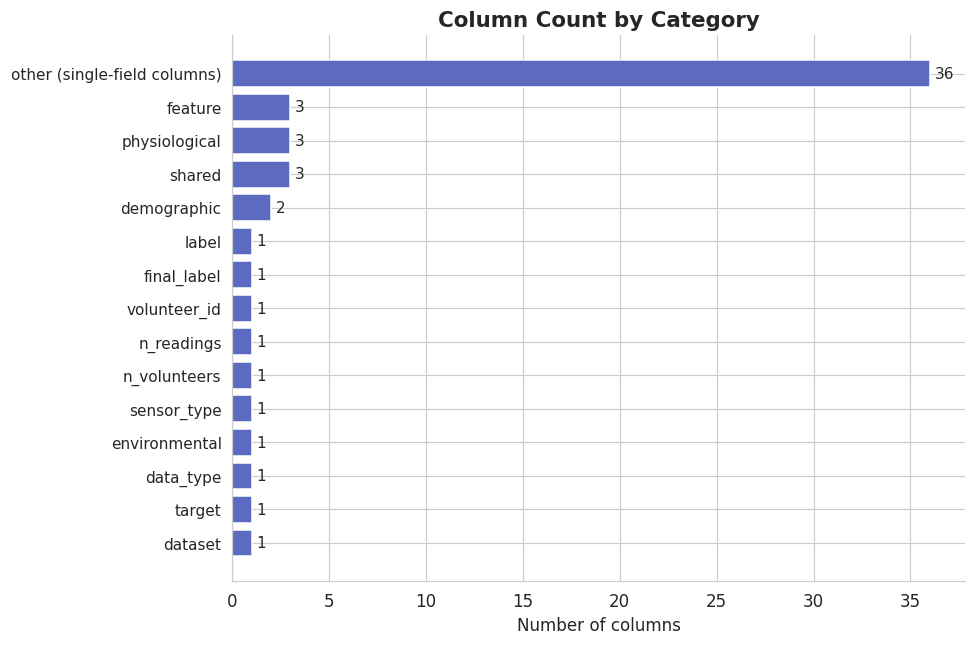

In [5]:
print(f"Shape: {df.shape[0]:,} rows  ×  {df.shape[1]} columns")

# ── Group columns by category prefix (only for true category__field naming) ──
# Columns without a '__' aren't part of the structured naming scheme (e.g. 'split',
# 'patientID', 'bvp_avg') — bucket those together instead of letting each become
# its own 1-column "category" and cluttering the chart.
def get_category(col):
    return col.split('__')[0] if '__' in col else 'other (single-field columns)'

cat_series = pd.Series([get_category(c) for c in df.columns])
prefix_counts = cat_series.value_counts()

print("\nColumns grouped by category prefix:")
display(prefix_counts.to_frame('column_count'))

# List which raw columns fell into "other" so nothing is hidden from the reader
other_cols = [c for c in df.columns if get_category(c) == 'other (single-field columns)']
if other_cols:
    print(f"\n'{'other (single-field columns)'}' contains {len(other_cols)} columns:")
    print(", ".join(other_cols))

# ── Publication figure ────────────────────────────────────────────────────────
plot_counts = prefix_counts.sort_values()

fig, ax = plt.subplots(figsize=(9, max(3.5, 0.4 * len(plot_counts))))
bars = ax.barh(plot_counts.index, plot_counts.values, color='#5C6BC0')
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_title('Column Count by Category', fontweight='bold', fontsize=14)
ax.set_xlabel('Number of columns', fontsize=11)
ax.tick_params(axis='y', labelsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('01_column_categories.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 4 · Data Types  `df.dtypes`

In [6]:
dtype_summary = df.dtypes.value_counts()
print("Data type breakdown:")
display(dtype_summary.to_frame('column_count'))

print("\nFull column -> dtype listing:")
display(df.dtypes.to_frame('dtype'))

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()
print(f"\nNumeric columns    : {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}  -> {categorical_cols}")


Data type breakdown:


,column_count
float64,41
object,9
int64,5
bool,2



Full column -> dtype listing:


,dtype
dataset__name_of_source_dataset,object
data_type__real_or_synthetic,object
sensor_type__optical_wavelengths_used,object
n_volunteers__total_subjects_in_study,int64
n_readings__total_measurement_sessions,int64
volunteer_id__unique_subject_identifier__1_to_96,float64
target__blood_glucose_mg_per_dL__primary_analyte__range_70_to_300,float64
feature__nir_signal_intensity_at_660nm__red_wavelength__higher_means_less_absorption,float64
feature__nir_signal_intensity_at_940nm__infrared_wavelength__higher_means_less_absorption,float64
feature__optical_ratio_660nm_divided_by_940nm__cancels_skin_thickness_and_melanin_noise,float64



Numeric columns    : 46
Categorical columns: 11  -> ['dataset__name_of_source_dataset', 'data_type__real_or_synthetic', 'sensor_type__optical_wavelengths_used', 'window_start_utc', 'glucose_reading_present', 'glucose_outlier_flag', 'patientID', 'split', 'skin_site_clean', 'dataset_split_clean', 'label_text']


## Step 5 · Missing Values  `df.isna().sum()`

✅ No missing values found in any of the 57 columns (15,720 rows checked).


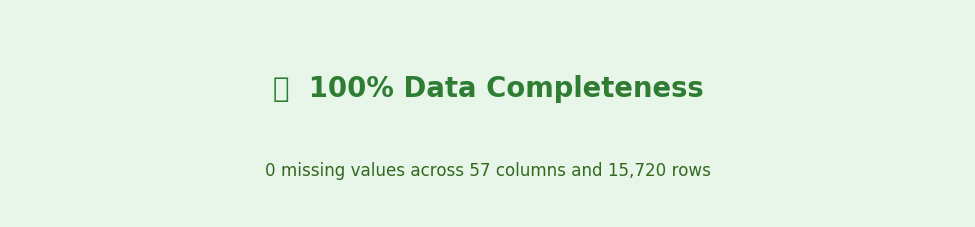

In [7]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_table = missing_table[missing_table['missing_count'] > 0]

if missing_table.empty:
    # ── No missing data: show a clean confirmation panel, not a blank heatmap ──
    print(f"✅ No missing values found in any of the {df.shape[1]} columns "
          f"({df.shape[0]:,} rows checked).")

    fig, ax = plt.subplots(figsize=(9, 2.2))
    ax.set_facecolor('#E8F5E9')
    fig.patch.set_facecolor('#E8F5E9')
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])
    ax.text(0.5, 0.62, '✅  100% Data Completeness', ha='center', va='center',
            fontsize=18, fontweight='bold', color='#2E7D32')
    ax.text(0.5, 0.22,
            f'0 missing values across {df.shape[1]} columns and {df.shape[0]:,} rows',
            ha='center', va='center', fontsize=11, color='#33691E')
    plt.tight_layout()
    plt.savefig('02_missing_values.png', dpi=300, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()

else:
    print(f"⚠️  {len(missing_table)} column(s) contain missing values:")
    display(missing_table)

    # Bar chart of % missing, only for affected columns
    fig, ax = plt.subplots(figsize=(9, max(3, 0.35 * len(missing_table))))
    missing_table['missing_pct'].sort_values().plot(kind='barh', color='#E53935', ax=ax)
    ax.set_xlabel('% Missing', fontsize=11)
    ax.set_title('Missing Values by Column', fontweight='bold', fontsize=14)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('02_missing_values.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ── Missingness heatmap — only affected columns, transposed & readable ──
    affected_cols = missing_table.index.tolist()
    sample_df = df[affected_cols].sample(min(2000, len(df)), random_state=42)

    fig, ax = plt.subplots(figsize=(10, max(3, 0.35 * len(affected_cols))))
    sns.heatmap(sample_df.isnull().T, cbar=False, cmap='Reds',
                xticklabels=False, yticklabels=True, ax=ax)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=9, rotation=0)
    ax.set_title('Missingness Map — affected columns only (sample of rows)',
                  fontweight='bold', fontsize=13)
    ax.set_xlabel('Row sample →')
    plt.tight_layout()
    plt.savefig('03_missingness_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

## Step 6 · Duplicate Rows  `df.duplicated().sum()`

In [8]:
n_dupes = df.duplicated().sum()
print(f"Fully duplicated rows: {n_dupes:,} ({n_dupes/len(df)*100:.3f}% of dataset)")

if TARGET and TARGET in df.columns:
    key_cols = TIER1 + [TARGET]
    key_cols = [c for c in key_cols if c in df.columns]
    if key_cols:
        n_dupe_signal = df.duplicated(subset=key_cols).sum()
        print(f"Rows with duplicated Tier-1 signal + label combo: {n_dupe_signal:,} "
              f"({n_dupe_signal/len(df)*100:.3f}%)")

if n_dupes > 0:
    display(df[df.duplicated(keep=False)].sort_values(by=df.columns[0]).head(10))
else:
    print("✅ No exact duplicate rows detected.")


Fully duplicated rows: 0 (0.000% of dataset)
Rows with duplicated Tier-1 signal + label combo: 9,069 (57.691%)
✅ No exact duplicate rows detected.


## Step 7 · Auto-Generated Data Dictionary

Since every column encodes its own description (`category__short_name__free_text_description`), this cell parses each column name into a **category**, **variable name**, and **human-readable description**, and pairs it with dtype, missing %, and cardinality. This table is exportable directly as the **"Variables description"** table required by Data in Brief.

In [9]:
def parse_column(col):
    parts = col.split('__')
    category = parts[0]
    var_name = parts[1] if len(parts) > 1 else parts[0]
    description = ' '.join(parts[2:]).replace('_', ' ').strip() if len(parts) > 2 else ''
    return category, var_name, description

rows = []
for c in df.columns:
    category, var_name, description = parse_column(c)
    rows.append({
        'column_name': c,
        'category': category,
        'short_name': var_name,
        'description': description if description else '(see column name)',
        'dtype': str(df[c].dtype),
        'missing_pct': round(df[c].isna().mean() * 100, 2),
        'n_unique': df[c].nunique(),
        'example_value': df[c].dropna().iloc[0] if df[c].notna().any() else None,
    })

data_dictionary = pd.DataFrame(rows)
pd.set_option('display.max_colwidth', 60)
display(data_dictionary)

data_dictionary.to_csv('data_dictionary.csv', index=False)
print("\n✅ Saved: data_dictionary.csv  (full variable description table for the manuscript)")


,column_name,category,short_name,description,dtype,missing_pct,n_unique,example_value
0,dataset__name_of_source_dataset,dataset,name_of_source_dataset,(see column name),object,0.0,5,PhysioCGM
1,data_type__real_or_synthetic,data_type,real_or_synthetic,(see column name),object,0.0,2,real
2,sensor_type__optical_wavelengths_used,sensor_type,optical_wavelengths_used,(see column name),object,0.0,1,660nm_red_plus_940nm_near_infrared
3,n_volunteers__total_subjects_in_study,n_volunteers,total_subjects_in_study,(see column name),int64,0.0,1,96
4,n_readings__total_measurement_sessions,n_readings,total_measurement_sessions,(see column name),int64,0.0,1,960
5,volunteer_id__unique_subject_identifier__1_to_96,volunteer_id,unique_subject_identifier,1 to 96,float64,0.0,5026,48.5
6,target__blood_glucose_mg_per_dL__primary_analyte__range_...,target,blood_glucose_mg_per_dL,primary analyte range 70 to 300,float64,0.0,15415,184.408333
7,feature__nir_signal_intensity_at_660nm__red_wavelength__...,feature,nir_signal_intensity_at_660nm,red wavelength higher means less absorption,float64,0.0,6590,651.069396
8,feature__nir_signal_intensity_at_940nm__infrared_wavelen...,feature,nir_signal_intensity_at_940nm,infrared wavelength higher means less absorption,float64,0.0,6588,547.072292
9,feature__optical_ratio_660nm_divided_by_940nm__cancels_s...,feature,optical_ratio_660nm_divided_by_940nm,cancels skin thickness and melanin noise,float64,0.0,6416,1.200732



✅ Saved: data_dictionary.csv  (full variable description table for the manuscript)


## Step 8 · Summary Statistics  `df.describe()`

In [10]:
print("=== Overall descriptive statistics (numeric columns) ===")
overall_desc = df[numeric_cols].describe().T
display(overall_desc)
overall_desc.to_csv('summary_statistics_overall.csv')

if TARGET and TARGET in df.columns:
    print(f"\n=== Descriptive statistics grouped by '{TARGET}' ===")
    grouped_desc = df.groupby(TARGET)[numeric_cols].agg(['mean', 'std']).T
    display(grouped_desc)
    grouped_desc.to_csv('summary_statistics_by_class.csv')
    print("\n✅ Saved: summary_statistics_overall.csv, summary_statistics_by_class.csv")


=== Overall descriptive statistics (numeric columns) ===


,count,mean,std,min,25%,50%,75%,max
n_volunteers__total_subjects_in_study,15720.0,96.000000,0.000000,96.000000,96.000000,96.000000,96.000000,96.000000
n_readings__total_measurement_sessions,15720.0,960.000000,0.000000,960.000000,960.000000,960.000000,960.000000,960.000000
volunteer_id__unique_subject_identifier__1_to_96,15720.0,48.217895,18.673716,1.000000,35.615602,47.400000,60.600000,96.000000
target__blood_glucose_mg_per_dL__primary_analyte__range_70_to_300,15720.0,160.481518,42.803191,70.300000,115.818545,183.863361,184.652466,299.800000
feature__nir_signal_intensity_at_660nm__red_wavelength__higher_means_less_absorption,15720.0,670.907988,43.923766,455.940000,643.466000,663.574000,700.171272,804.260000
feature__nir_signal_intensity_at_940nm__infrared_wavelength__higher_means_less_absorption,15720.0,574.402116,54.832746,384.390000,532.818000,565.196000,616.434000,720.830000
feature__optical_ratio_660nm_divided_by_940nm__cancels_skin_thickness_and_melanin_noise,15720.0,1.178379,0.062511,0.966400,1.141160,1.183227,1.223460,1.531800
physiological__heart_rate_bpm__beats_per_minute__range_50_to_120,15720.0,77.937287,13.148670,50.000000,69.280000,77.245550,85.780000,109.100000
physiological__blood_oxygen_saturation_percent__SpO2__range_90_to_100,15720.0,97.920739,0.794413,93.300000,97.480000,97.949898,98.360000,100.000000
physiological__skin_surface_temperature_celsius__affects_NIR_absorption,15720.0,32.987124,0.755222,28.000000,32.550000,32.986938,33.506031,36.890000



=== Descriptive statistics grouped by 'shared__label_is_diabetic' ===


shared__label_is_diabetic                                        0            1
n_volunteers__total_subjects_in_study            mean    96.000000    96.000000
                                                 std      0.000000     0.000000
n_readings__total_measurement_sessions           mean   960.000000   960.000000
                                                 std      0.000000     0.000000
volunteer_id__unique_subject_identifier__1_to_96 mean    48.596127    48.028779
...                                                            ...          ...
label_has_DM2                                    std      0.327705     0.000000
n_spectral_channels                              mean  3160.000000  3160.000000
                                                 std      0.000000     0.000000
final_label__is_diabetic                         mean     0.000000     1.000000
                                                 std      0.000000     0.000000

[92 rows x 2 columns]


✅ Saved: summary_statistics_overall.csv, summary_statistics_by_class.csv


## Step 9 · Class Distribution & Dataset Composition

Reproduces the full composition dashboard: target class balance, real-vs-synthetic split, contributing source datasets, and the train/validation/test partition — the core **"Experimental design"** figures for the manuscript.

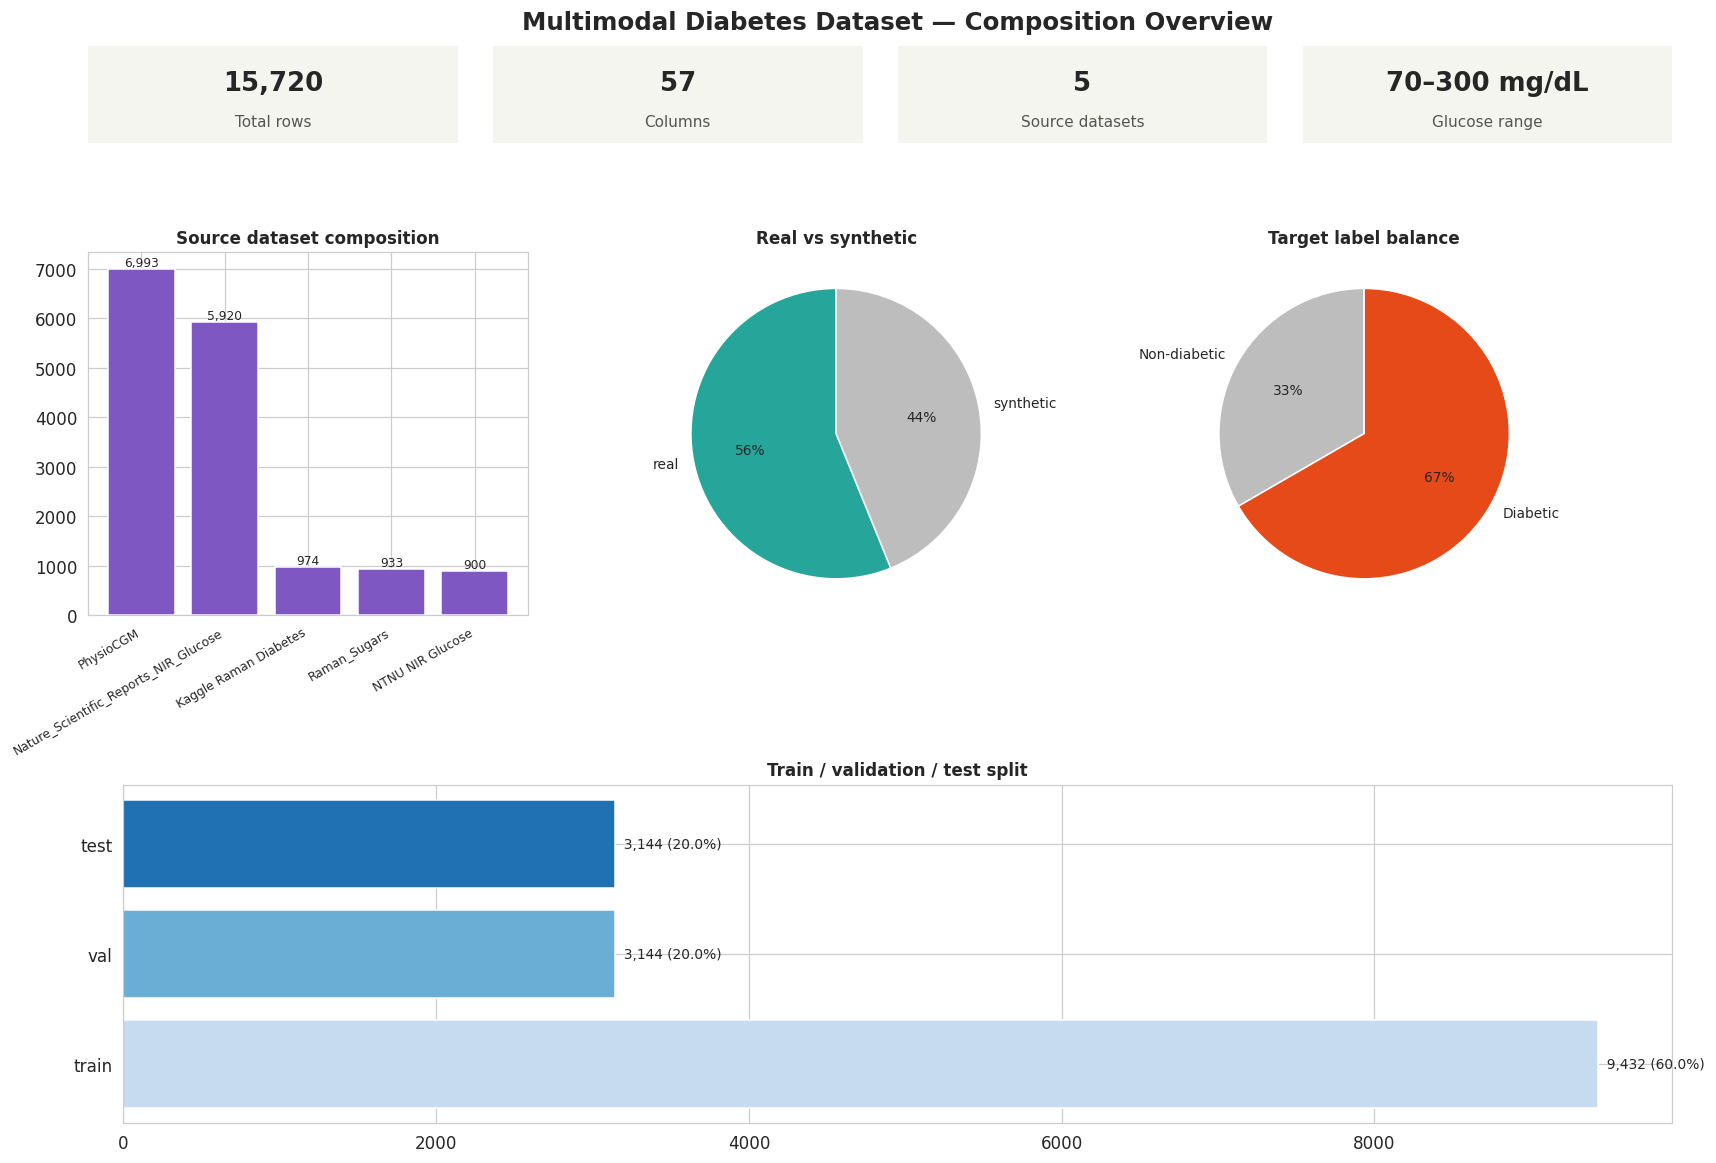

=== Numeric summary ===
shared__label_is_diabetic
1    66.7
0    33.3 

dataset__name_of_source_dataset
PhysioCGM                                6993
Nature_Scientific_Reports_NIR_Glucose    5920
Kaggle Raman Diabetes                     974
Raman_Sugars                              933
NTNU NIR Glucose                          900 

data_type__real_or_synthetic
real         8826
synthetic    6894 

split
train    9432
val      3144
test     3144


In [11]:
fig = plt.figure(figsize=(16, 11))
fig.suptitle('Multimodal Diabetes Dataset — Composition Overview', fontsize=16, fontweight='bold', y=0.98)

# Headline metric boxes
metrics = [
    (f"{len(df):,}", "Total rows"),
    (f"{df.shape[1]}", "Columns"),
]
if COL['source_dataset']:
    metrics.append((f"{df[COL['source_dataset']].nunique()}", "Source datasets"))
if COL['glucose_value']:
    gmin, gmax = df[COL['glucose_value']].min(), df[COL['glucose_value']].max()
    metrics.append((f"{gmin:.0f}–{gmax:.0f} mg/dL", "Glucose range"))

for i, (val, lbl) in enumerate(metrics):
    ax = fig.add_axes([0.04 + i * (0.92/len(metrics)), 0.87, 0.92/len(metrics) - 0.02, 0.08])
    ax.set_facecolor('#F5F5F0')
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.text(0.5, 0.62, val, ha='center', va='center', fontsize=17, fontweight='bold')
    ax.text(0.5, 0.22, lbl, ha='center', va='center', fontsize=10, color='#555')

row_y = 0.48
plot_idx = 0
n_plots = sum([bool(COL['source_dataset']), bool(COL['real_synthetic']), bool(TARGET)])
width = 0.90 / max(n_plots, 1)

if COL['source_dataset']:
    ax1 = fig.add_axes([0.04 + plot_idx * width, row_y, width - 0.05, 0.30])
    vc = df[COL['source_dataset']].value_counts()
    ax1.bar(range(len(vc)), vc.values, color='#7E57C2')
    ax1.set_xticks(range(len(vc))); ax1.set_xticklabels(vc.index, rotation=30, ha='right', fontsize=8)
    ax1.set_title('Source dataset composition', fontweight='bold', fontsize=11)
    for i, v in enumerate(vc.values):
        ax1.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=8)
    plot_idx += 1

if COL['real_synthetic']:
    ax2 = fig.add_axes([0.04 + plot_idx * width, row_y, width - 0.05, 0.30])
    vc = df[COL['real_synthetic']].value_counts()
    ax2.pie(vc.values, labels=vc.index, autopct='%1.0f%%', colors=['#26A69A', '#BDBDBD'],
            startangle=90, textprops={'fontsize': 9})
    ax2.set_title('Real vs synthetic', fontweight='bold', fontsize=11)
    plot_idx += 1

if TARGET:
    ax3 = fig.add_axes([0.04 + plot_idx * width, row_y, width - 0.05, 0.30])
    vc = df[TARGET].value_counts().sort_index()
    lbls = ['Non-diabetic', 'Diabetic'] if set(vc.index) <= {0, 1} else vc.index.astype(str)
    ax3.pie(vc.values, labels=lbls, autopct='%1.0f%%', colors=['#BDBDBD', '#E64A19'],
            startangle=90, textprops={'fontsize': 9})
    ax3.set_title('Target label balance', fontweight='bold', fontsize=11)

# Train/val/test split bar
if COL['split']:
    ax4 = fig.add_axes([0.06, 0.06, 0.88, 0.28])
    vc = df[COL['split']].value_counts()
    colors_split = sns.color_palette('Blues', len(vc))
    ax4.barh(vc.index.astype(str), vc.values, color=colors_split)
    ax4.set_title('Train / validation / test split', fontweight='bold', fontsize=11)
    for i, (idx, v) in enumerate(vc.items()):
        ax4.text(v, i, f'  {v:,} ({v/len(df)*100:.1f}%)', va='center', fontsize=9)

plt.savefig('04_dataset_composition.png', bbox_inches='tight')
plt.show()

# Printed summary
print("=== Numeric summary ===")
if TARGET:
    print(df[TARGET].value_counts(normalize=True).mul(100).round(1).to_string(), "\n")
if COL['source_dataset']:
    print(df[COL['source_dataset']].value_counts().to_string(), "\n")
if COL['real_synthetic']:
    print(df[COL['real_synthetic']].value_counts().to_string(), "\n")
if COL['split']:
    print(df[COL['split']].value_counts().to_string())


## Step 10 · Correlation Analysis & Feature Tiering  `df.corr()`

Computes Pearson correlation of every numeric feature against the target label, replicating the tiering scheme from the companion report:
- **Tier 1** — strong (`|r| > 0.4`), optical NIR signals
- **Tier 2** — moderate (`0.05 < |r| < 0.4`), wearable signals
- **Tier 3** — negligible (`|r| < 0.05`), demographic/environmental

=== Pearson correlation with target (sorted) ===


,correlation
feature__nir_signal_intensity_at_940nm__infrared_wavelength__higher_means_less_absorption,-0.719352
feature__nir_signal_intensity_at_660nm__red_wavelength__higher_means_less_absorption,-0.670148
row_completeness_score,-0.138648
bvp_variability,-0.096947
bvp_max,-0.095355
movement_intensity_peak,-0.070813
movement_intensity_variability,-0.057218
wrist_temp_variability_C,-0.021805
physiological__blood_oxygen_saturation_percent__SpO2__range_90_to_100,-0.015209
volunteer_id__unique_subject_identifier__1_to_96,-0.014323


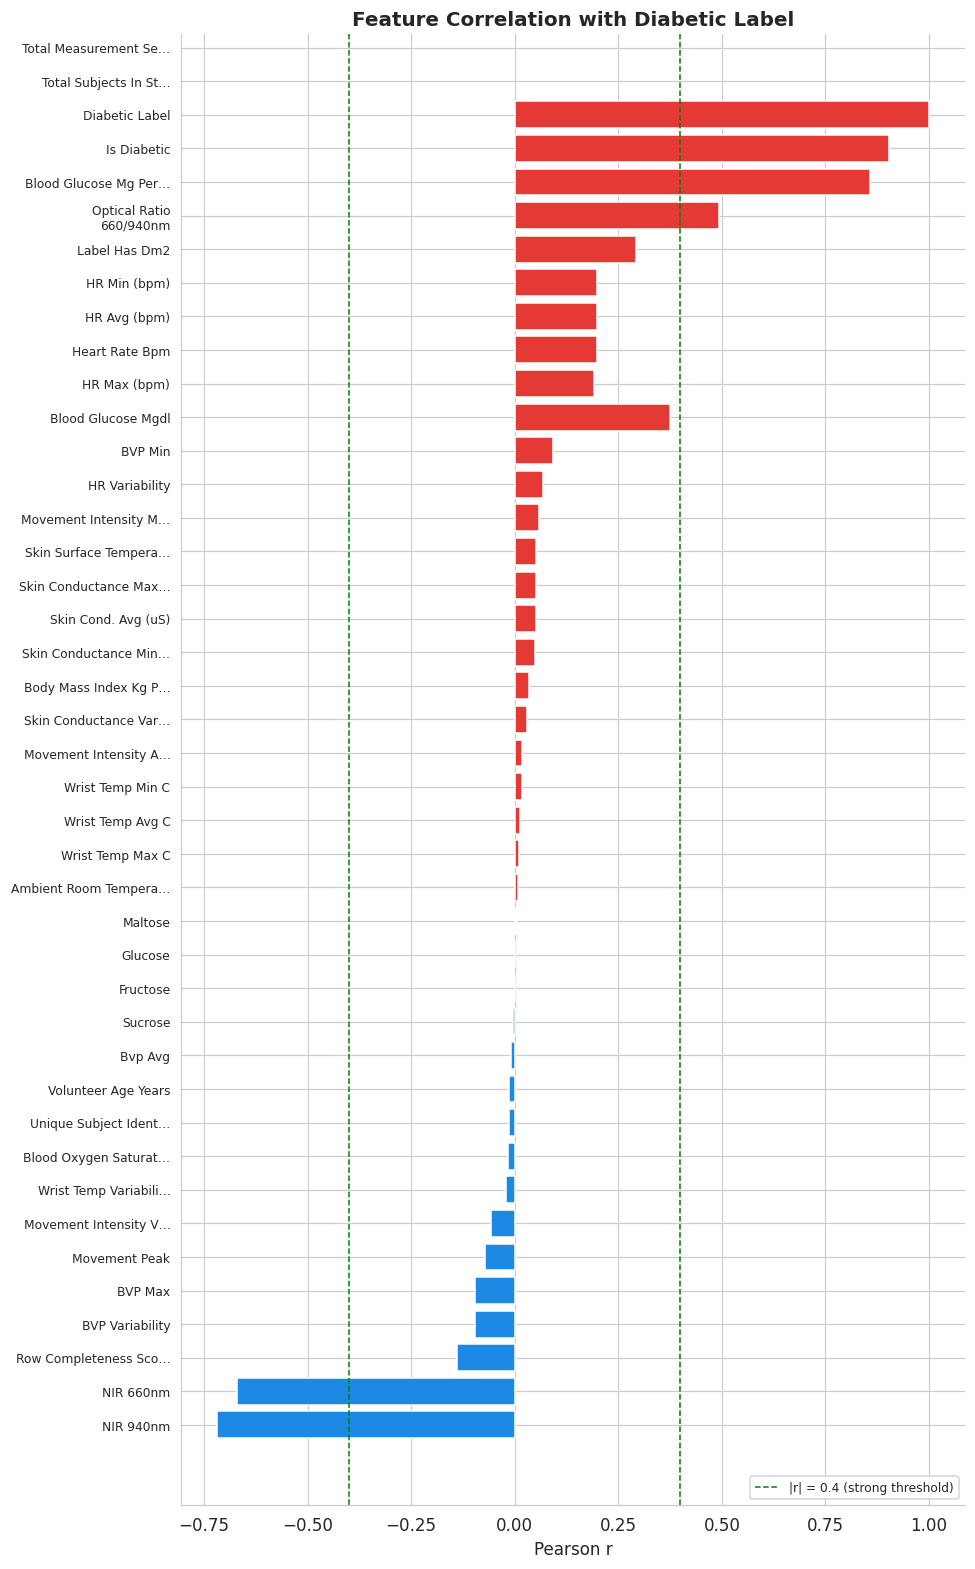

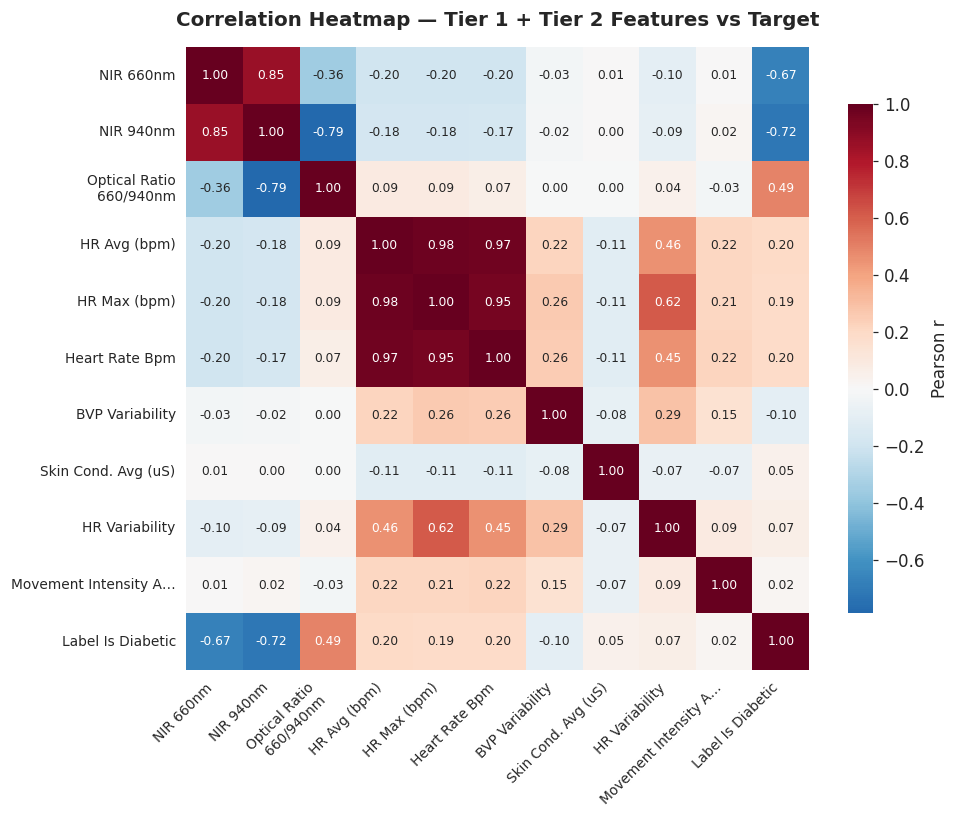


✅ Saved: correlation_with_target.csv


In [13]:
# ── Short, publication-friendly display labels for the known feature set ────
SHORT_LABEL = {
    'feature__nir_signal_intensity_at_660nm__red_wavelength__higher_means_less_absorption': 'NIR 660nm',
    'feature__nir_signal_intensity_at_940nm__infrared_wavelength__higher_means_less_absorption': 'NIR 940nm',
    'feature__optical_ratio_660nm_divided_by_940nm__cancels_skin_thickness_and_melanin_noise': 'Optical Ratio\n660/940nm',
    'heart_rate_avg_bpm': 'HR Avg (bpm)',
    'heart_rate_max_bpm': 'HR Max (bpm)',
    'heart_rate_min_bpm': 'HR Min (bpm)',
    'heart_rate_variability_bpm': 'HR Variability',
    'bvp_variability': 'BVP Variability',
    'bvp_max': 'BVP Max',
    'bvp_min': 'BVP Min',
    'skin_conductance_avg_uS': 'Skin Cond. Avg (uS)',
    'movement_intensity_peak': 'Movement Peak',
    'final_label__is_diabetic': 'Diabetic Label',
}

def short_label(col):
    """Falls back to an auto-shortened label for any column not in the map above,
    so this keeps working even if TIER1/TIER2 are edited later."""
    if col in SHORT_LABEL:
        return SHORT_LABEL[col]
    parts = col.split('__')
    base = parts[1] if len(parts) >= 2 else parts[0]
    label = base.replace('_', ' ').title()
    return (label[:20] + '…') if len(label) > 20 else label

if TARGET:
    corr_features = [c for c in numeric_cols if c != TARGET]
    corr_with_target = df[corr_features + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()

    print("=== Pearson correlation with target (sorted) ===")
    display(corr_with_target.to_frame('correlation'))

    def tier_of(r):
        if abs(r) > 0.4: return 'Tier 1 (strong)'
        if abs(r) > 0.05: return 'Tier 2 (moderate)'
        return 'Tier 3 (negligible)'

    tier_table = corr_with_target.to_frame('correlation')
    tier_table['tier'] = tier_table['correlation'].apply(tier_of)
    tier_table.to_csv('correlation_with_target.csv')

    # ── Bar chart, using short labels ────────────────────────────────────────
    bar_labels = [short_label(c) for c in corr_with_target.index]
    fig, ax = plt.subplots(figsize=(9, max(5, 0.32 * len(corr_with_target))))
    bar_colors = ['#E53935' if v > 0 else '#1E88E5' for v in corr_with_target.values]
    ax.barh(bar_labels, corr_with_target.values, color=bar_colors)
    ax.axvline(0.4, color='green', ls='--', lw=1, label='|r| = 0.4 (strong threshold)')
    ax.axvline(-0.4, color='green', ls='--', lw=1)
    ax.set_title(f'Feature Correlation with Diabetic Label', fontweight='bold', fontsize=13)
    ax.set_xlabel('Pearson r', fontsize=11)
    ax.tick_params(axis='y', labelsize=8)
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('05_correlation_with_target.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ── Heatmap, using short labels for both axes ────────────────────────────
    heat_cols = TIER1 + TIER2 + [TARGET]
    heat_cols = [c for c in heat_cols if c in df.columns]
    heat_labels = [short_label(c) for c in heat_cols]

    corr_matrix = df[heat_cols].corr()
    corr_matrix.index = heat_labels
    corr_matrix.columns = heat_labels

    fig, ax = plt.subplots(figsize=(9, 7.5))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                square=True, cbar_kws={'label': 'Pearson r', 'shrink': 0.8},
                annot_kws={'size': 8}, ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
    ax.set_title('Correlation Heatmap — Tier 1 + Tier 2 Features vs Target',
                 fontweight='bold', fontsize=13, pad=14)
    plt.tight_layout()
    plt.savefig('06_correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n✅ Saved: correlation_with_target.csv")
else:
    print("⚠️  Target column not found — skipping correlation analysis.")

## Step 11 · Univariate Distributions — Histograms & Boxplots by Class

For each Tier 1 (optical) and Tier 2 (wearable) feature: overlapping histograms split by class, plus a boxplot to visualize spread/outliers. Clear separation between the diabetic/non-diabetic distributions is the visual justification for the feature tiering.

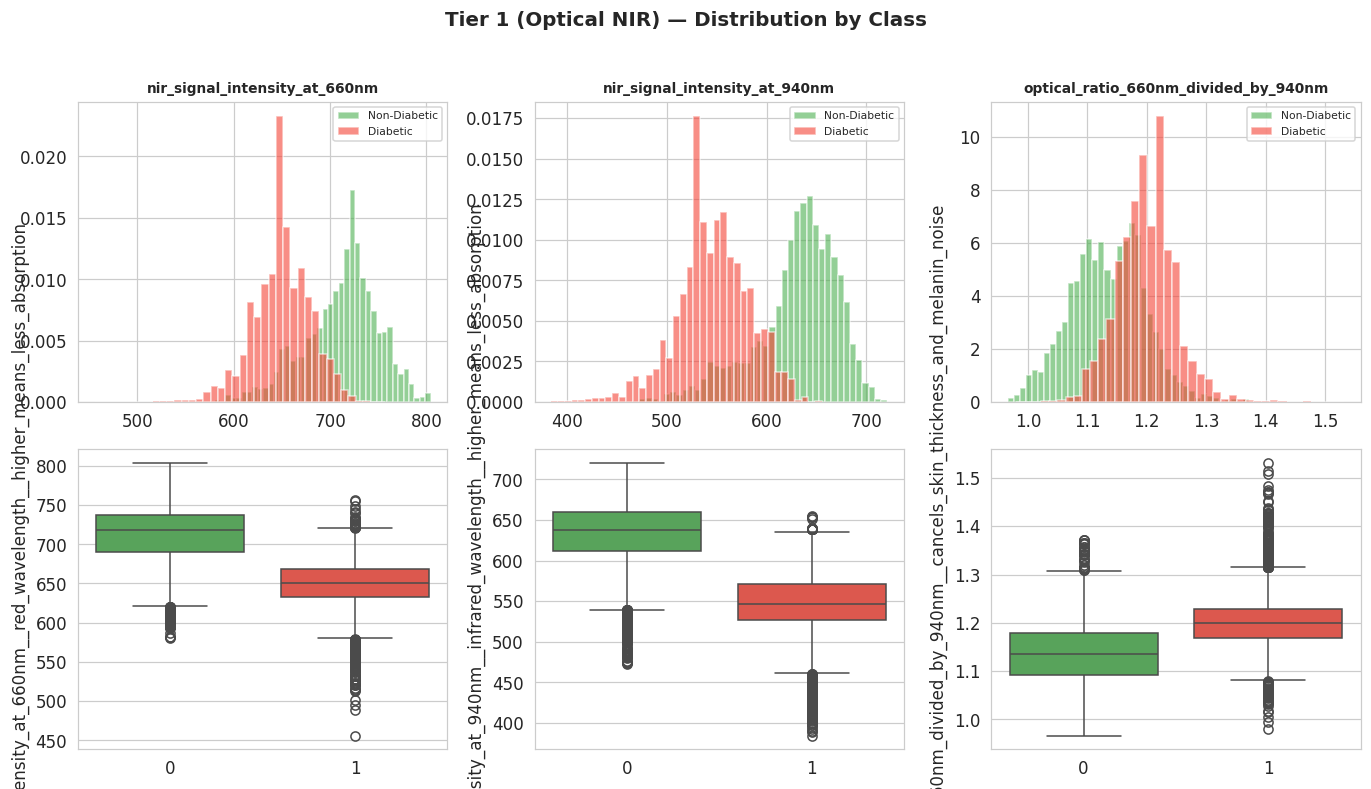

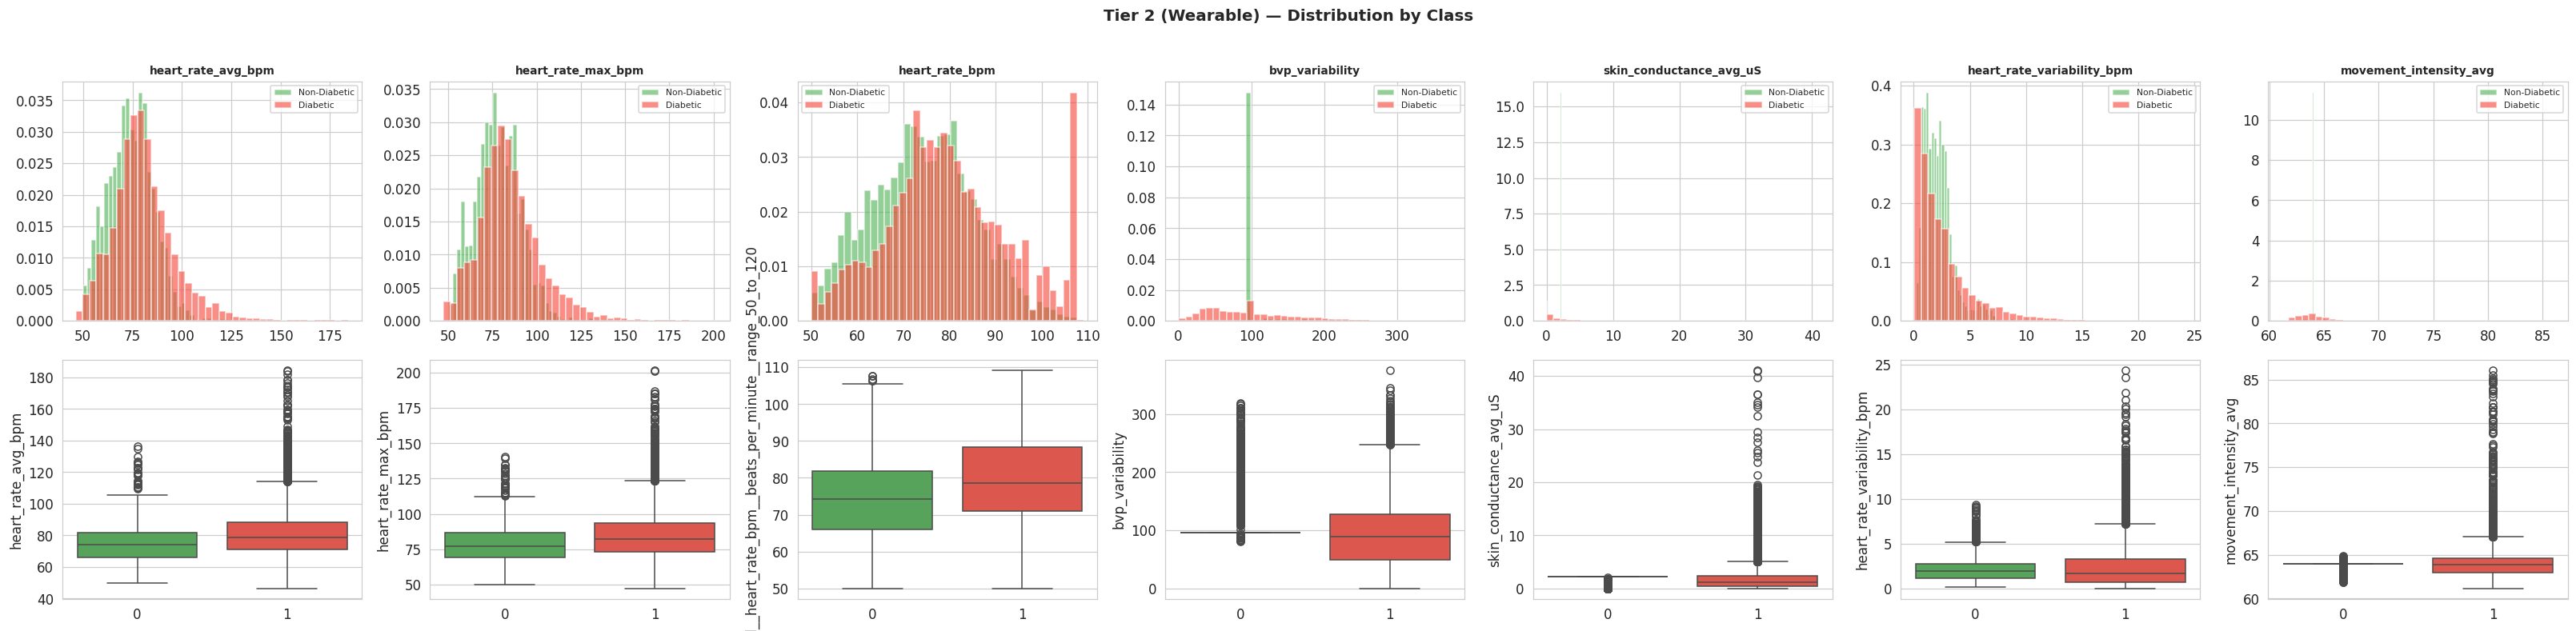

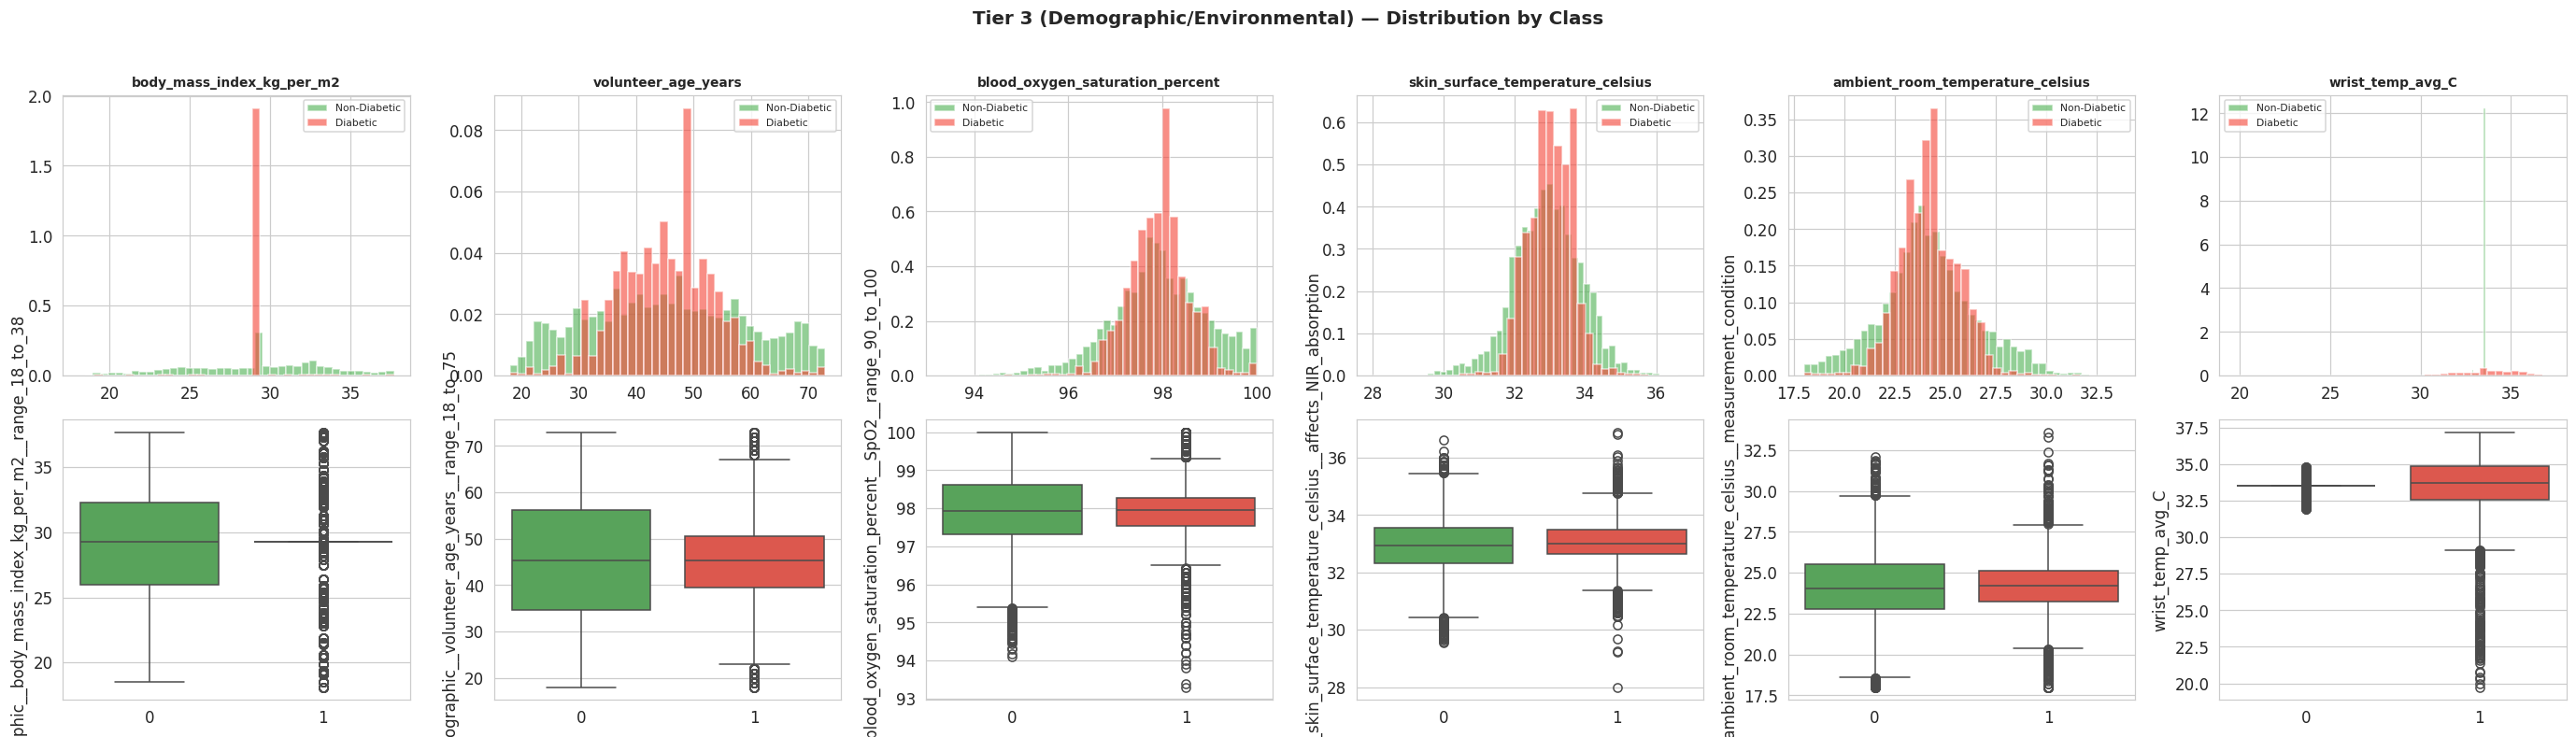

In [14]:
def plot_tier_distributions(feature_list, tier_name, filename):
    if not feature_list or not TARGET:
        print(f"⚠️  Skipping {tier_name}: no features or target found.")
        return
    n = len(feature_list)
    fig, axes = plt.subplots(2, n, figsize=(4.2 * n, 7))
    if n == 1:
        axes = axes.reshape(2, 1)
    colors = {0: '#4CAF50', 1: '#F44336'}
    classes = sorted(df[TARGET].dropna().unique())
    labels_map = {classes[0]: 'Class 0', classes[-1]: 'Class 1'} if len(classes) == 2 else {}
    if set(classes) <= {0, 1}:
        labels_map = {0: 'Non-Diabetic', 1: 'Diabetic'}

    for j, col in enumerate(feature_list):
        # Histogram
        ax = axes[0, j]
        for cls in classes:
            subset = df[df[TARGET] == cls][col].dropna()
            ax.hist(subset, bins=40, alpha=0.6, density=True,
                    color=colors.get(cls, None), label=labels_map.get(cls, str(cls)))
        ax.set_title(col.split('__')[1] if '__' in col else col, fontsize=9, fontweight='bold')
        ax.legend(fontsize=7)

        # Boxplot
        ax2 = axes[1, j]
        sns.boxplot(x=TARGET, y=col, data=df, ax=ax2, palette=[colors.get(c) for c in classes])
        ax2.set_xlabel('')

    plt.suptitle(f'{tier_name} — Distribution by Class', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight')
    plt.show()

plot_tier_distributions(TIER1, 'Tier 1 (Optical NIR)', '07_tier1_distributions.png')
plot_tier_distributions(TIER2, 'Tier 2 (Wearable)',   '08_tier2_distributions.png')
plot_tier_distributions(TIER3, 'Tier 3 (Demographic/Environmental)', '09_tier3_distributions.png')


## Step 12 · Bivariate Analysis — Scatter Plots

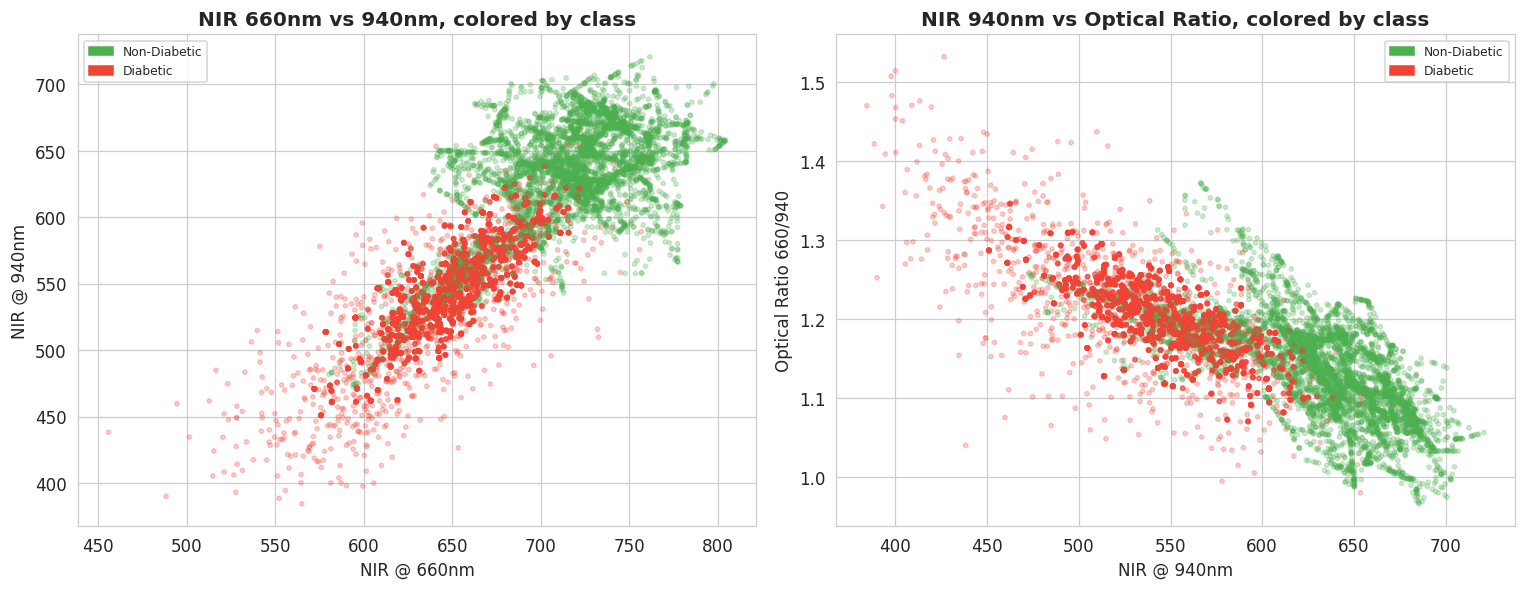

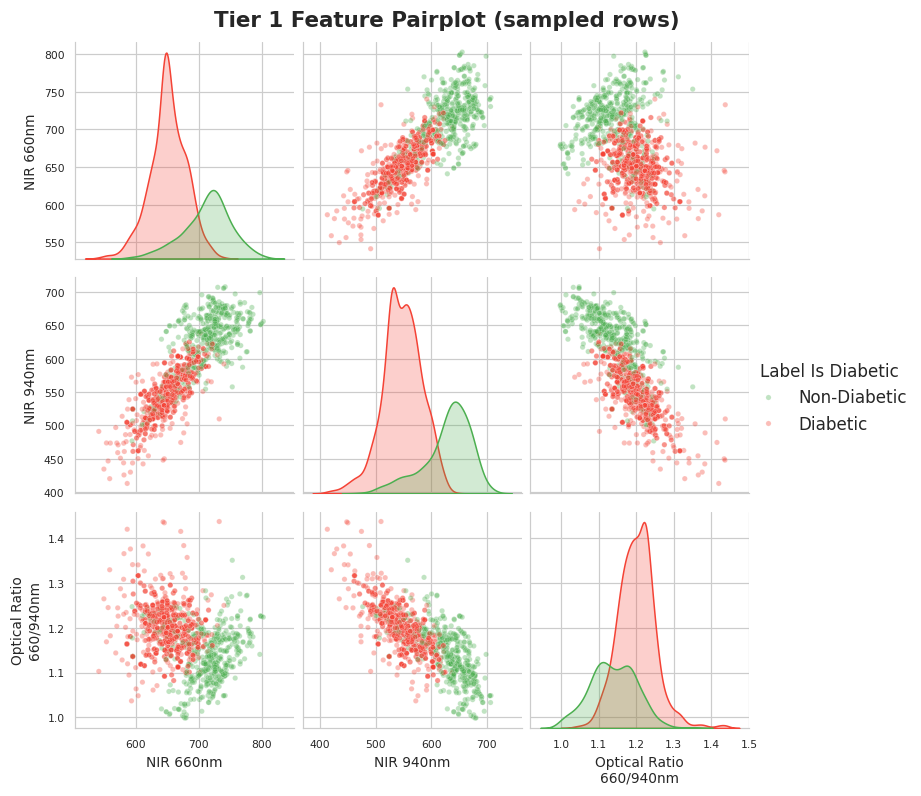

In [17]:
# ── Reuse the short_label() helper from Step 10 (define here if running standalone) ──
SHORT_LABEL = {
    'feature__nir_signal_intensity_at_660nm__red_wavelength__higher_means_less_absorption': 'NIR 660nm',
    'feature__nir_signal_intensity_at_940nm__infrared_wavelength__higher_means_less_absorption': 'NIR 940nm',
    'feature__optical_ratio_660nm_divided_by_940nm__cancels_skin_thickness_and_melanin_noise': 'Optical Ratio\n660/940nm',
    'final_label__is_diabetic': 'Diabetic Label',
}
def short_label(col):
    if col in SHORT_LABEL:
        return SHORT_LABEL[col]
    parts = col.split('__')
    base = parts[1] if len(parts) >= 2 else parts[0]
    label = base.replace('_', ' ').title()
    return (label[:20] + '…') if len(label) > 20 else label

if COL['nir_940'] and COL['nir_660'] and TARGET:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    colors_map = df[TARGET].map({0: '#4CAF50', 1: '#F44336'}) if set(df[TARGET].dropna().unique()) <= {0,1} else None
    axes[0].scatter(df[COL['nir_660']], df[COL['nir_940']], c=colors_map, alpha=0.25, s=8)
    axes[0].set_xlabel('NIR @ 660nm'); axes[0].set_ylabel('NIR @ 940nm')
    axes[0].set_title('NIR 660nm vs 940nm, colored by class', fontweight='bold')
    handles = [mpatches.Patch(color='#4CAF50', label='Non-Diabetic'),
               mpatches.Patch(color='#F44336', label='Diabetic')]
    axes[0].legend(handles=handles, fontsize=8)

    if COL['optical_ratio']:
        axes[1].scatter(df[COL['nir_940']], df[COL['optical_ratio']], c=colors_map, alpha=0.25, s=8)
        axes[1].set_xlabel('NIR @ 940nm'); axes[1].set_ylabel('Optical Ratio 660/940')
        axes[1].set_title('NIR 940nm vs Optical Ratio, colored by class', fontweight='bold')
        axes[1].legend(handles=handles, fontsize=8)

    plt.tight_layout()
    plt.savefig('10_scatter_tier1.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠️  Skipping scatter analysis — NIR columns or target not found.")

# ── Pairplot of Tier 1 features, colored by class (sampled for speed) ───────
if len(TIER1) >= 2 and TARGET:
    sample = df.sample(min(1500, len(df)), random_state=42)
    plot_cols = TIER1 + [TARGET]

    # Rename to short labels BEFORE plotting — seaborn pulls axis/legend labels
    # straight from the column names, which is what was causing the overlap.
    sample_renamed = sample[plot_cols].rename(columns=short_label)
    target_short = short_label(TARGET)

    g = sns.pairplot(sample_renamed, hue=target_short, palette={0: '#4CAF50', 1: '#F44336'},
                      diag_kind='kde', plot_kws={'alpha': 0.35, 's': 12}, height=2.4)
    g.fig.suptitle('Tier 1 Feature Pairplot (sampled rows)', y=1.02, fontweight='bold', fontsize=14)

    for ax in g.axes.flatten():
        if ax is not None:
            ax.set_xlabel(ax.get_xlabel(), fontsize=9)
            ax.set_ylabel(ax.get_ylabel(), fontsize=9)
            ax.tick_params(labelsize=7)

    if g._legend is not None:
        g._legend.set_title(target_short)
        for t, lbl in zip(g._legend.texts, ['Non-Diabetic', 'Diabetic']):
            t.set_text(lbl)

    g.savefig('11_pairplot_tier1.png', dpi=300, bbox_inches='tight')
    plt.show()

## Step 13 · Group Mean Comparison & Statistical Significance

For every Tier 1 + Tier 2 feature: group means/std by class, an independent-samples **t-test** (is the difference in means statistically significant?), and **Cohen's d** (how large is the effect, independent of sample size?). This directly validates Tables 5.1 and 6.1 of the companion report using this notebook's own copy of the data.

In [18]:
def cohens_d(a, b):
    na, nb = len(a), len(b)
    pooled_std = np.sqrt(((na - 1) * a.std(ddof=1)**2 + (nb - 1) * b.std(ddof=1)**2) / (na + nb - 2))
    return (a.mean() - b.mean()) / pooled_std if pooled_std > 0 else np.nan

if TARGET:
    classes = sorted(df[TARGET].dropna().unique())
    rows = []
    for col in TIER1 + TIER2 + TIER3:
        g0 = df[df[TARGET] == classes[0]][col].dropna()
        g1 = df[df[TARGET] == classes[-1]][col].dropna()
        if len(g0) < 2 or len(g1) < 2:
            continue
        t_stat, p_val = stats.ttest_ind(g0, g1, equal_var=False)
        d = cohens_d(g1, g0)
        rows.append({
            'feature': col, f'mean_class_{classes[0]}': g0.mean(), f'mean_class_{classes[-1]}': g1.mean(),
            'p_value': p_val, 'significant_p<0.05': p_val < 0.05, 'cohens_d': d
        })
    stat_table = pd.DataFrame(rows).sort_values('cohens_d', key=abs, ascending=False)
    display(stat_table)
    stat_table.to_csv('group_comparison_stats.csv', index=False)
    print("\n✅ Saved: group_comparison_stats.csv")
else:
    print("⚠️  Target not found — skipping statistical tests.")


,feature,mean_class_0,mean_class_1,p_value,significant_p<0.05,cohens_d
1,feature__nir_signal_intensity_at_940nm__infrared_wavelen...,630.182655,546.511846,0.000000e+00,True,-2.196630
0,feature__nir_signal_intensity_at_660nm__red_wavelength__...,712.534654,650.094654,0.000000e+00,True,-1.915193
2,feature__optical_ratio_660nm_divided_by_940nm__cancels_s...,1.134713,1.200211,0.000000e+00,True,1.205014
3,heart_rate_avg_bpm,74.377484,80.591325,3.076744e-169,True,0.429840
5,physiological__heart_rate_bpm__beats_per_minute__range_5...,74.262378,79.774741,1.996705e-156,True,0.427655
4,heart_rate_max_bpm,78.045784,84.680585,3.919366e-156,True,0.411351
6,bvp_variability,106.449885,95.752696,1.295382e-47,True,-0.206615
8,heart_rate_variability_bpm,2.206009,2.524245,7.487475e-25,True,0.143659
13,physiological__skin_surface_temperature_celsius__affects...,32.931532,33.014920,1.065044e-08,True,0.110561
7,skin_conductance_avg_uS,1.935510,2.198872,3.318200e-18,True,0.108295



✅ Saved: group_comparison_stats.csv


## Step 14 · Outlier Detection (IQR Method)

,feature,lower_bound,upper_bound,n_outliers,pct_outliers,iqr_collapsed_flag
10,demographic__body_mass_index_kg_per_m2__range_18_to_38,29.253856,29.254520,5322,33.85,True
9,movement_intensity_avg,62.192405,65.196396,2287,14.55,False
15,wrist_temp_avg_C,31.587604,35.922771,1881,11.97,False
7,skin_conductance_avg_uS,-1.931925,4.665924,1508,9.59,False
6,bvp_variability,0.003407,177.990539,1452,9.24,False
8,heart_rate_variability_bpm,-2.243455,6.213587,1025,6.52,False
12,physiological__blood_oxygen_saturation_percent__SpO2__ra...,96.160000,99.680000,672,4.27,False
14,environmental__ambient_room_temperature_celsius__measure...,19.970000,28.370000,627,3.99,False
3,heart_rate_avg_bpm,44.468133,110.616223,489,3.11,False
4,heart_rate_max_bpm,43.452062,119.452391,448,2.85,False


⚠️  1 column(s) have a near-zero IQR relative to their full range (dense clustering around one value) — their outlier % is not a meaningful indicator of true extreme values. Inspect the distribution directly. Columns:
demographic__body_mass_index_kg_per_m2__range_18_to_38


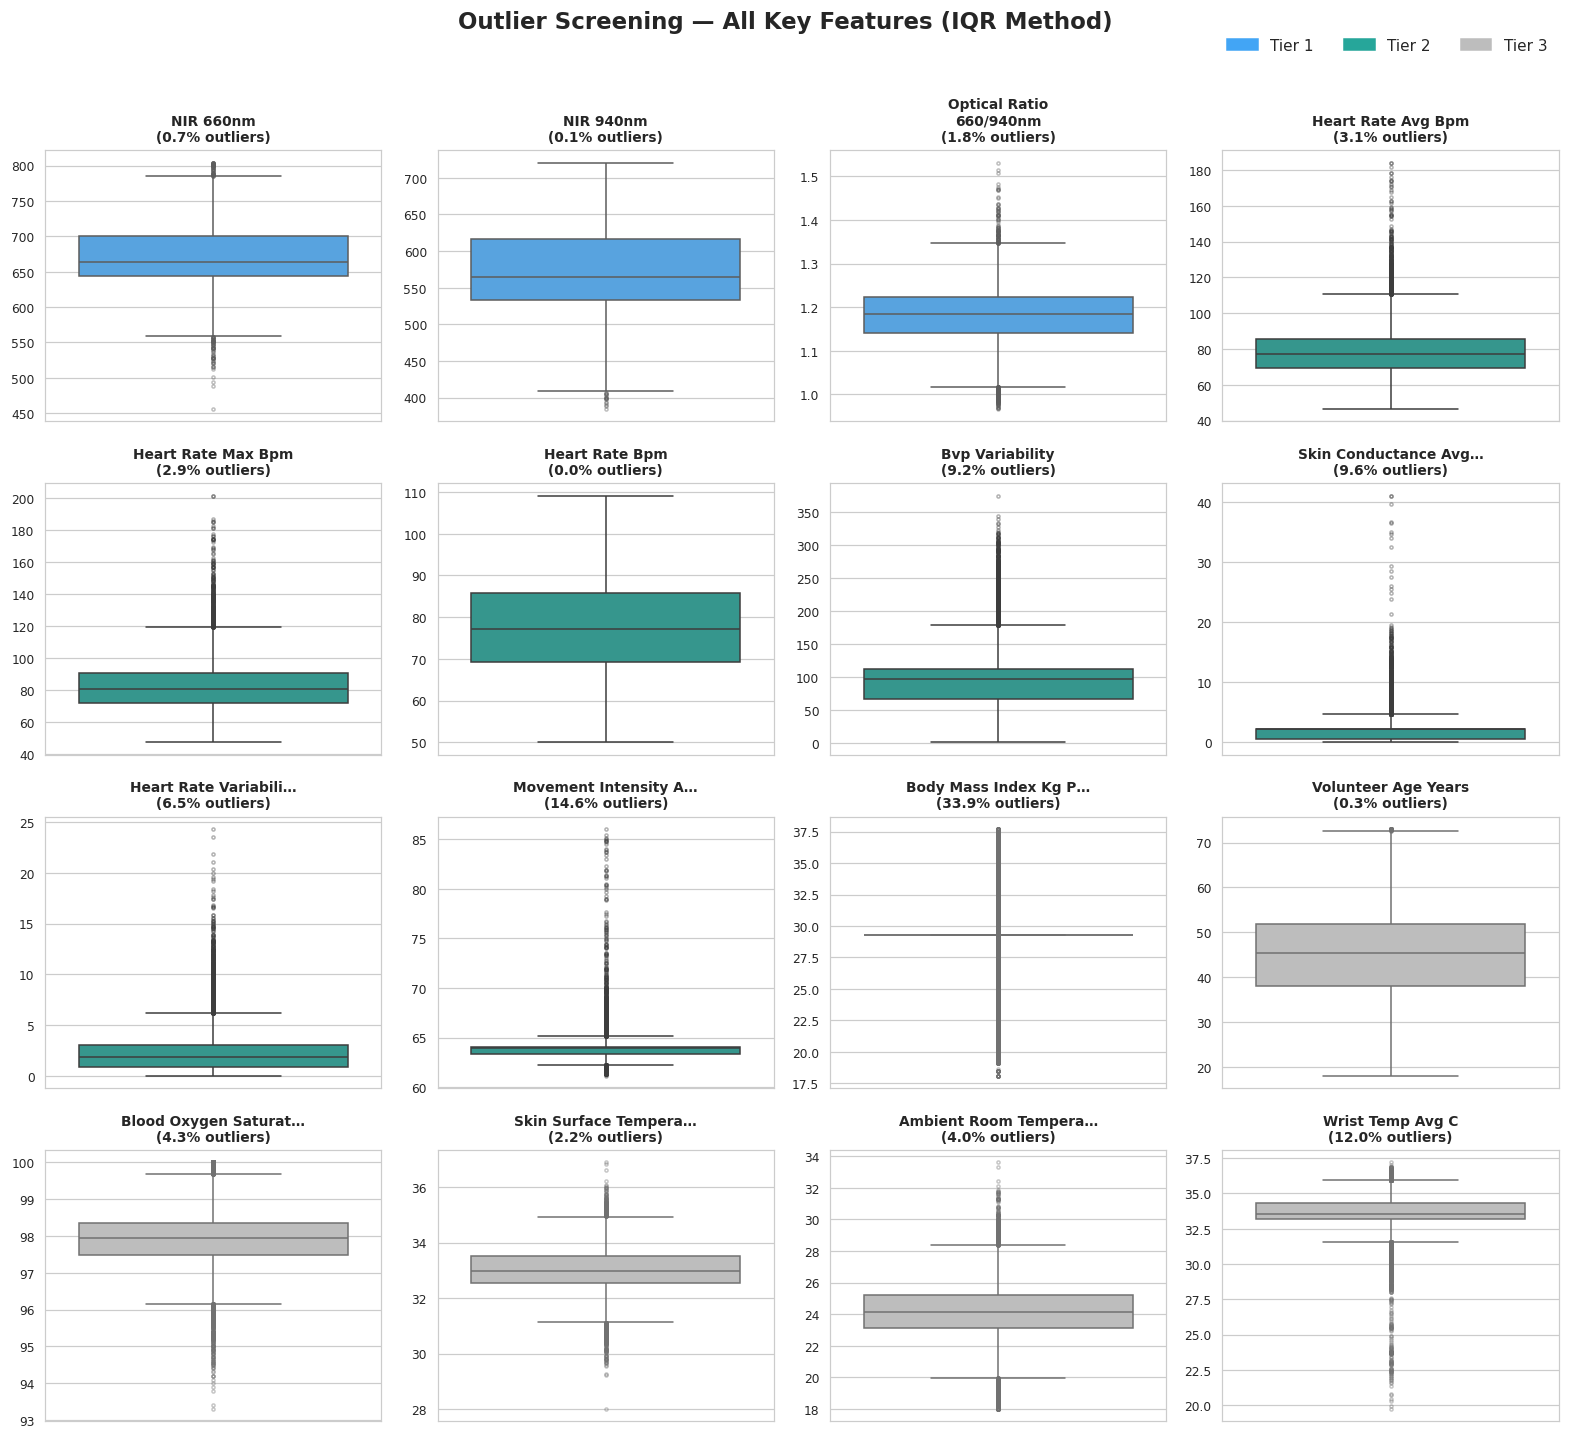


✅ Saved: outlier_summary.csv


In [20]:
outlier_rows = []
check_cols = [c for c in TIER1 + TIER2 + TIER3 if c in df.columns]

for col in check_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    full_range = df[col].max() - df[col].min()
    # Flag columns where the IQR has effectively collapsed to a point relative
    # to the column's overall range — the 1.5*IQR rule isn't meaningful there,
    # and a high "% outliers" number would be misleading rather than informative.
    degenerate = full_range > 0 and (iqr / full_range) < 0.01
    outlier_rows.append({'feature': col, 'lower_bound': lower, 'upper_bound': upper,
                          'n_outliers': n_out, 'pct_outliers': round(n_out / len(df) * 100, 2),
                          'iqr_collapsed_flag': degenerate})

outlier_table = pd.DataFrame(outlier_rows).sort_values('pct_outliers', ascending=False)
display(outlier_table)
outlier_table.to_csv('outlier_summary.csv', index=False)

flagged = outlier_table[outlier_table['iqr_collapsed_flag']]
if not flagged.empty:
    print(f"⚠️  {len(flagged)} column(s) have a near-zero IQR relative to their full range "
          f"(dense clustering around one value) — their outlier % is not a meaningful indicator "
          f"of true extreme values. Inspect the distribution directly. Columns:")
    print(", ".join(flagged['feature']))

# ── Tier color-coding for the paper figure ───────────────────────────────────
TIER_COLOR = {'Tier 1': '#42A5F5', 'Tier 2': '#26A69A', 'Tier 3': '#BDBDBD'}
tier_of_col = {c: 'Tier 1' for c in TIER1}
tier_of_col.update({c: 'Tier 2' for c in TIER2})
tier_of_col.update({c: 'Tier 3' for c in TIER3})
pct_lookup = dict(zip(outlier_table['feature'], outlier_table['pct_outliers']))

if check_cols:
    n = len(check_cols)
    ncols = 4
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.6 * ncols, 3.2 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(check_cols):
        tier = tier_of_col.get(col, 'Tier 3')
        sns.boxplot(y=df[col], ax=axes[i], color=TIER_COLOR[tier],
                    flierprops={'markersize': 2, 'alpha': 0.4})
        pct = pct_lookup.get(col, 0)
        axes[i].set_title(f"{short_label(col)}\n({pct:.1f}% outliers)", fontsize=9, fontweight='bold')
        axes[i].set_ylabel('')
        axes[i].tick_params(labelsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in TIER_COLOR.values()]
    fig.legend(handles, TIER_COLOR.keys(), loc='upper right', ncol=3, fontsize=10,
               bbox_to_anchor=(0.99, 1.01), frameon=False)
    plt.suptitle('Outlier Screening — All Key Features (IQR Method)',
                 fontweight='bold', fontsize=15, y=1.02)
    plt.tight_layout()
    plt.savefig('12_outlier_boxplots.png', dpi=300, bbox_inches='tight')
    plt.show()
print("\n✅ Saved: outlier_summary.csv")

## Step 15 · Unique Value / Cardinality Check  `df[col].nunique()`

In [21]:
cardinality = df.nunique().sort_values()
display(cardinality.to_frame('n_unique'))

print("\n=== Value counts for low-cardinality (categorical-like) columns ===")
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().to_string())


,n_unique
n_volunteers__total_subjects_in_study,1
sensor_type__optical_wavelengths_used,1
n_readings__total_measurement_sessions,1
n_spectral_channels,1
shared__label_is_diabetic,2
glucose_outlier_flag,2
glucose_reading_present,2
data_type__real_or_synthetic,2
row_completeness_score,2
final_label__is_diabetic,2



=== Value counts for low-cardinality (categorical-like) columns ===

--- dataset__name_of_source_dataset ---
dataset__name_of_source_dataset
PhysioCGM                                6993
Nature_Scientific_Reports_NIR_Glucose    5920
Kaggle Raman Diabetes                     974
Raman_Sugars                              933
NTNU NIR Glucose                          900

--- data_type__real_or_synthetic ---
data_type__real_or_synthetic
real         8826
synthetic    6894

--- sensor_type__optical_wavelengths_used ---
sensor_type__optical_wavelengths_used
660nm_red_plus_940nm_near_infrared    15720

--- window_start_utc ---
window_start_utc
9/23/2022 15:17     3
5/20/2022 17:40     3
6/28/2022 18:19     2
11/13/2022 1:54     2
8/24/2022 20:13     2
5/31/2022 18:49     2
11/4/2022 12:42     2
9/23/2022 20:00     2
10/1/2022 5:40      2
6/12/2022 14:44     2
7/20/2022 2:11      2
5/31/2022 17:50     2
6/12/2022 13:50     2
10/31/2022 3:25     2
5/20/2022 18:10     2
6/15/2022 19:06     2
9

## Step 16 · Consistency & Sanity Checks

Validates internal logical consistency of the dataset — the kind of check a *Data in Brief* reviewer will expect to see documented: does the label actually agree with the stated clinical threshold? Are physiological values in a plausible range?

In [22]:
print("=== Sanity checks ===\n")

# 1. Label vs glucose threshold consistency (126 mg/dL)
if TARGET and COL['glucose_value']:
    implied_label = (df[COL['glucose_value']] > 126).astype(int)
    mismatch = (implied_label != df[TARGET]).sum()
    print(f"1. Label vs 126 mg/dL threshold consistency: {mismatch:,} mismatches out of {len(df):,} rows "
          f"({mismatch/len(df)*100:.3f}%)")
else:
    print("1. ⚠️  Could not run — glucose value column or target not found.")

# 2. Glucose physiological range check (expected ~70-300 mg/dL per report)
if COL['glucose_value']:
    out_of_range = ((df[COL['glucose_value']] < 40) | (df[COL['glucose_value']] > 500)).sum()
    print(f"2. Glucose values outside plausible physiological range (40-500 mg/dL): {out_of_range:,}")
    print(f"   Actual observed range: {df[COL['glucose_value']].min():.1f} – {df[COL['glucose_value']].max():.1f} mg/dL")
else:
    print("2. ⚠️  Glucose column not found — skipped.")

# 3. SpO2 plausibility (should be 70-100%)
if COL['spo2']:
    bad_spo2 = ((df[COL['spo2']] < 70) | (df[COL['spo2']] > 100)).sum()
    print(f"3. SpO2 values outside plausible range (70-100%): {bad_spo2:,}")

# 4. Heart rate plausibility (30-220 bpm)
if COL['hr_avg']:
    bad_hr = ((df[COL['hr_avg']] < 30) | (df[COL['hr_avg']] > 220)).sum()
    print(f"4. Avg heart rate values outside plausible range (30-220 bpm): {bad_hr:,}")

# 5. Negative values in columns that should be non-negative (NIR intensities)
for name, col in [('NIR 940nm', COL['nir_940']), ('NIR 660nm', COL['nir_660'])]:
    if col:
        n_neg = (df[col] < 0).sum()
        print(f"5. Negative values in {name}: {n_neg:,}")

print("\nIf any counts above are non-zero and unexpected, investigate those rows before finalizing the release.")


=== Sanity checks ===

1. Label vs 126 mg/dL threshold consistency: 657 mismatches out of 15,720 rows (4.179%)
2. Glucose values outside plausible physiological range (40-500 mg/dL): 0
   Actual observed range: 70.3 – 299.8 mg/dL
3. SpO2 values outside plausible range (70-100%): 0
4. Avg heart rate values outside plausible range (30-220 bpm): 0
5. Negative values in NIR 940nm: 0
5. Negative values in NIR 660nm: 0

If any counts above are non-zero and unexpected, investigate those rows before finalizing the release.


## Step 17 · "Value of the Data" — Auto-Generated Narrative Summary

*Data in Brief* requires an explicit **"Value of the Data"** section. This cell programmatically pulls the strongest correlations, class balance, and dataset size directly from the computations above and drafts a starting-point paragraph you can edit — ensuring every number quoted in the manuscript text is traceable to a cell in this notebook.

In [23]:
summary_lines = []
summary_lines.append(f"This dataset comprises {len(df):,} measurement sessions across {df.shape[1]} columns, "
                      f"combining optical (near-infrared), wearable physiological, and demographic signals.")

if TARGET:
    vc = df[TARGET].value_counts(normalize=True).mul(100).round(1)
    summary_lines.append(f"The target label is distributed as: " +
                          ", ".join(f"class {k} = {v}%" for k, v in vc.items()) + ".")

if COL['real_synthetic']:
    vc = df[COL['real_synthetic']].value_counts(normalize=True).mul(100).round(1)
    summary_lines.append(f"Real vs. synthetic composition: " +
                          ", ".join(f"{k} = {v}%" for k, v in vc.items()) + ".")

if TARGET and 'corr_with_target' in dir():
    pass

try:
    top_pos = corr_with_target.idxmax()
    top_neg = corr_with_target.idxmin()
    summary_lines.append(f"The strongest positive correlate of the target is '{top_pos}' "
                          f"(r={corr_with_target[top_pos]:.2f}); the strongest negative correlate is "
                          f"'{top_neg}' (r={corr_with_target[top_neg]:.2f}).")
except NameError:
    pass

try:
    n_sig = stat_table['significant_p<0.05'].sum()
    summary_lines.append(f"Of {len(stat_table)} candidate non-invasive features tested, {n_sig} showed a "
                          f"statistically significant (p<0.05) difference in means between classes.")
except NameError:
    pass

n_missing_cols = (df.isnull().sum() > 0).sum()
summary_lines.append(f"Data quality checks found {n_missing_cols} column(s) with missing values and "
                      f"{df.duplicated().sum()} fully duplicated rows out of {len(df):,}.")

value_of_data_text = "\n\n".join(summary_lines)
print(value_of_data_text)

with open('value_of_data_summary.txt', 'w') as f:
    f.write(value_of_data_text)
print("\n✅ Saved: value_of_data_summary.txt")


This dataset comprises 15,720 measurement sessions across 57 columns, combining optical (near-infrared), wearable physiological, and demographic signals.

The target label is distributed as: class 1 = 66.7%, class 0 = 33.3%.

Real vs. synthetic composition: real = 56.1%, synthetic = 43.9%.

The strongest positive correlate of the target is 'final_label__is_diabetic' (r=1.00); the strongest negative correlate is 'feature__nir_signal_intensity_at_940nm__infrared_wavelength__higher_means_less_absorption' (r=-0.72).

Of 16 candidate non-invasive features tested, 13 showed a statistically significant (p<0.05) difference in means between classes.

Data quality checks found 0 column(s) with missing values and 0 fully duplicated rows out of 15,720.

✅ Saved: value_of_data_summary.txt


## Step 18 · Export All Figures & Tables for the Manuscript

In [24]:
outputs = [
    '01_column_categories.png', '02_missing_values.png', '03_missingness_heatmap.png',
    '04_dataset_composition.png', '05_correlation_with_target.png', '06_correlation_heatmap.png',
    '07_tier1_distributions.png', '08_tier2_distributions.png', '09_tier3_distributions.png',
    '10_scatter_tier1.png', '11_pairplot_tier1.png', '12_outlier_boxplots.png',
    'data_dictionary.csv', 'summary_statistics_overall.csv', 'summary_statistics_by_class.csv',
    'correlation_with_target.csv', 'group_comparison_stats.csv', 'outlier_summary.csv',
    'value_of_data_summary.txt',
]

existing = [f for f in outputs if os.path.exists(f)]
missing_files = [f for f in outputs if f not in existing]

print(f"Found {len(existing)}/{len(outputs)} output files.")
if missing_files:
    print("Not generated (an earlier optional cell may have been skipped):")
    for f in missing_files:
        print(f"  - {f}")

with zipfile.ZipFile('EDA_outputs_for_manuscript.zip', 'w') as zf:
    for f in existing:
        zf.write(f)

print("\n✅ Packaged: EDA_outputs_for_manuscript.zip")
files.download('EDA_outputs_for_manuscript.zip')


Found 19/19 output files.

✅ Packaged: EDA_outputs_for_manuscript.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion

This notebook produced a complete, reproducible EDA of the multimodal non-invasive diabetes / blood-glucose dataset: structural description, data-quality checks, composition breakdowns, correlation-based feature tiering, distribution and outlier analysis, and significance testing — everything needed to write the **Description of Data**, **Experimental Design, Materials and Methods**, and **Value of the Data** sections of a *Data in Brief* submission.

**Before submitting**, double-check:
- All auto-detected column names above actually matched the intended fields (Step "Column Auto-Detection")
- The `value_of_data_summary.txt` numbers are copied into the manuscript text and cross-checked against the underlying tables (`.csv` files in the exported zip)
- Any non-zero counts from Step 16 (sanity checks) have been investigated and resolved or explained
- Figures are re-exported at final resolution/style if the journal has specific figure requirements

**Note on scope:** this notebook is intentionally an EDA/documentation notebook, not a predictive-modeling notebook — it makes no train/test split for model fitting and trains no classifiers, since a Data in Brief submission documents the dataset itself rather than a downstream model's performance.
